# Úvod a popis zadání

Cílem bylo vybrat si vhodný dataset a na něm otestovat několik klasifikačních modelů, stanovit nějaký baseline model a dále testovat další modely. Vybrat ten nejlepší a ten upravit tak, aby byl co nejvhodnější.

Vybral jsem si dataset GTSRB - German Traffic Sign Recognition Benchmark.

Jako baseline model jsem použil Logistic Regression s RGB vstupem.

Další použité modely:
- Linear Support Vector Classifier (LinearSVC)    + Grayscale + PCA
- Random Forest                                   + Grayscale + Raw Pixels*
- Random Forest                                   + RGB + Raw Pixels*
- K-Nearest Neighbors (KNN)                       + Grayscale + Raw Pixels*
- Decision Tree                                   + Grayscale + Raw Pixels*

Jediný model, u kterého jsem se rozhodl použít variantu jak RGB tak Grayscale z důvodu dobrých výsledků a i rychlosti je Random Forest.

Ještě bych chtěl upozornit, jelikož píši u každého modelu jak dlouho trval a i to porovnávám, že můj notebook má procesor Intel i9 - 14900HX, díky čemuž se mohou časy lišit, kdyby se modely zpouštěly například v Googlu colabu nebo na jiném zařízení.

U všech výsledků, co se týká převážně výsledků jako jsou časy inference, je velice pravděpodobné, že se po opakovaném spuštění budou lišit od těch co Já uvádím. Ty mé výsledky jsou uvedeny jako příklad toho co mi vyšlo a z čeho jsem Já vycházel.

*Raw pixels je myšleno, že jsem nijak neupravoval vstupní počet pixelů, tím jsem se zabýval až později u jednoho vybraného nejlepšího modelu

# Importy

In [11]:
import os
import cv2  # Pro práci s obrázky
import time
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.models import load_model

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.decomposition import PCA
from matplotlib.colors import LogNorm

# Nastavení projektu

In [2]:
IMG_SIZE = 64
train_path = "data/Train"
test_path = "data/Test"
RANDOM_STATE = 42

# Funkce pro načítání dat

In [3]:
def load_dataset(train_path, img_size=64, grayscale=False):

    X = []
    y = []

    classes = sorted(os.listdir(train_path))

    print("Načítání datasetu...")

    for cls in classes:

        class_path = os.path.join(train_path, cls)

        for image_name in os.listdir(class_path):

            image_path = os.path.join(class_path, image_name)

            # načtení obrázku
            img = cv2.imread(image_path)

            # grayscale nebo RGB
            if grayscale:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            else:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            # resize
            img = cv2.resize(img, (img_size, img_size))

            # normalizace
            img = img / 255.0

            # flatten
            img = img.flatten()

            X.append(img)
            y.append(int(cls))

    X = np.array(X)
    y = np.array(y)

    print("Dataset načten.")
    print("Shape X:", X.shape)
    print("Shape y:", y.shape)

    return X, y

# GRAYSCALE DATASET

In [4]:
X_gray, y_gray = load_dataset(
    train_path=train_path,
    img_size=64,
    grayscale=True
)

X_train_gray, X_test_gray, y_train_gray, y_test_gray = train_test_split(
    X_gray,
    y_gray,
    test_size=0.2,
    random_state=42,
    stratify=y_gray
)

print("Train samples:", len(X_train_gray))
print("Test samples:", len(X_test_gray))

Načítání datasetu...
Dataset načten.
Shape X: (39209, 4096)
Shape y: (39209,)
Train samples: 31367
Test samples: 7842


# RGB DATASET

In [5]:
X_rgb, y_rgb = load_dataset(
    train_path=train_path,
    img_size=64,
    grayscale=False
)

X_train_rgb, X_test_rgb, y_train_rgb, y_test_rgb = train_test_split(
    X_rgb,
    y_rgb,
    test_size=0.2,
    random_state=42,
    stratify=y_rgb
)

print("Train samples:", len(X_train_rgb))
print("Test samples:", len(X_test_rgb))

Načítání datasetu...
Dataset načten.
Shape X: (39209, 12288)
Shape y: (39209,)
Train samples: 31367
Test samples: 7842


# Pomocné funkce pro zobrazení špatně a dobře zařazených obrázků

In [6]:
def show_top_wrong_predictions(
    X_test,
    y_test,
    y_pred,
    y_prob,
    X_train,
    y_train,
    img_size=64,
    grayscale=True,
    top_n=5
):

    # confidence score
    confidence = np.max(y_prob, axis=1)

    # špatně klasifikované
    wrong_indices = np.where(y_test != y_pred)[0]

    # confidence špatných predikcí
    wrong_confidence = confidence[wrong_indices]

    # seřazení od nejjistějších chyb
    sorted_wrong = wrong_indices[np.argsort(-wrong_confidence)]

    # TOP N
    top_wrong = sorted_wrong[:top_n]

    plt.figure(figsize=(12, top_n * 4))

    for i, idx in enumerate(top_wrong):

        # ============================================
        # Špatně klasifikovaný obrázek
        # ============================================

        plt.subplot(top_n, 2, i*2 + 1)

        if grayscale:
            img = X_test[idx].reshape(img_size, img_size)
            plt.imshow(img, cmap="gray")
        else:
            img = X_test[idx].reshape(img_size, img_size, 3)
            plt.imshow(img)

        plt.title(
            f"TEST IMAGE\n"
            f"True: {y_test[idx]}\n"
            f"Pred: {y_pred[idx]}\n"
            f"Prob: {confidence[idx]*100:.2f}%"
        )

        plt.axis("off")

        # ============================================
        # Referenční obrázek predikované třídy
        # ============================================

        predicted_class_indices = np.where(
            y_train == y_pred[idx]
        )[0]

        random_pred_idx = np.random.choice(
            predicted_class_indices
        )

        plt.subplot(top_n, 2, i*2 + 2)

        if grayscale:
            pred_img = X_train[random_pred_idx].reshape(
                img_size,
                img_size
            )
            plt.imshow(pred_img, cmap="gray")
        else:
            pred_img = X_train[random_pred_idx].reshape(
                img_size,
                img_size,
                3
            )
            plt.imshow(pred_img)

        plt.title(
            f"PREDICTED CLASS\n"
            f"Class: {y_pred[idx]}"
        )

        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [7]:
def show_top_correct_predictions(
    X_test,
    y_test,
    y_pred,
    y_prob,
    img_size=64,
    grayscale=True,
    top_n=10
):

    # confidence score
    confidence = np.max(y_prob, axis=1)

    # správně klasifikované
    correct_indices = np.where(y_test == y_pred)[0]

    # confidence pouze pro správné
    correct_confidence = confidence[correct_indices]

    # seřazení od nejjistějších
    sorted_correct = correct_indices[np.argsort(-correct_confidence)]

    # top N
    top_correct = sorted_correct[:top_n]

    plt.figure(figsize=(15,20))

    for i, idx in enumerate(top_correct):

        plt.subplot(top_n//2, 2, i+1)

        if grayscale:
            img = X_test[idx].reshape(img_size, img_size)
            plt.imshow(img, cmap="gray")
        else:
            img = X_test[idx].reshape(img_size, img_size, 3)
            plt.imshow(img)

        plt.title(
            f"True: {y_test[idx]}\n"
            f"Pred: {y_pred[idx]}\n"
            f"Prob: {confidence[idx]*100:.2f}%"
        )

        plt.axis("off")

    plt.tight_layout()
    plt.show()

# ANALÝZA DATASETU

Zjistím si počet tříd, dále kolik jaká třída obsahuje obrázků, abych věděl zda jich někde není příliž málo.
Následně si ukážu 10 náhodných značek, jak vypadají v originálu (RGB) a následně po Grayscale úpravě.

In [8]:
classes = sorted(os.listdir(train_path), key=int)

print("Počet tříd:", len(classes))
print("Třídy:", classes)

Počet tříd: 43
Třídy: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42']


In [9]:
class_counts = {}

for cls in classes:
    class_path = os.path.join(train_path, cls)
    class_counts[cls] = len(os.listdir(class_path))

class_counts

{'0': 210,
 '1': 2220,
 '2': 2250,
 '3': 1410,
 '4': 1980,
 '5': 1860,
 '6': 420,
 '7': 1440,
 '8': 1410,
 '9': 1470,
 '10': 2010,
 '11': 1320,
 '12': 2100,
 '13': 2160,
 '14': 780,
 '15': 630,
 '16': 420,
 '17': 1110,
 '18': 1200,
 '19': 210,
 '20': 360,
 '21': 330,
 '22': 390,
 '23': 510,
 '24': 270,
 '25': 1500,
 '26': 600,
 '27': 240,
 '28': 540,
 '29': 270,
 '30': 450,
 '31': 780,
 '32': 240,
 '33': 689,
 '34': 420,
 '35': 1200,
 '36': 390,
 '37': 210,
 '38': 2070,
 '39': 300,
 '40': 360,
 '41': 240,
 '42': 240}

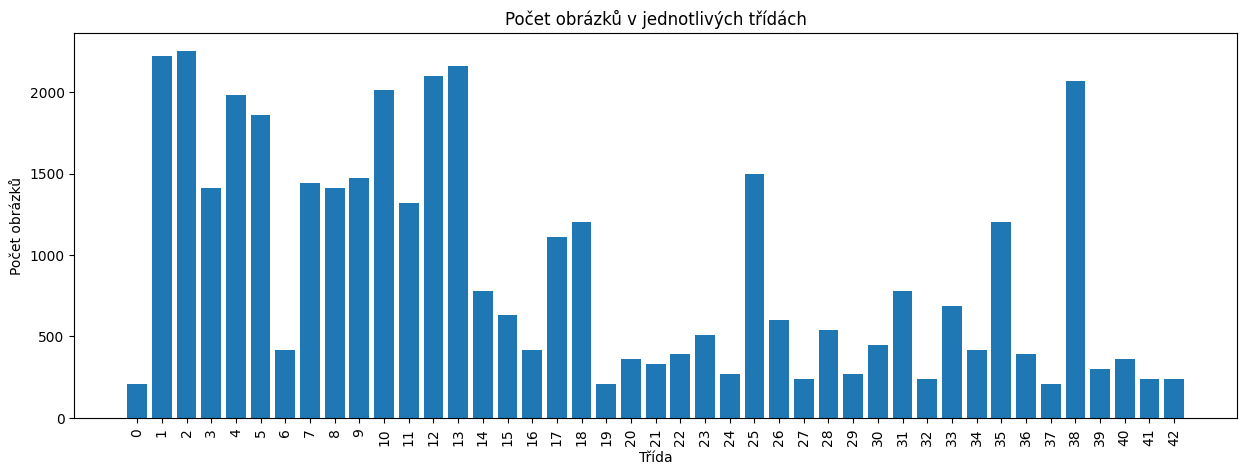

In [10]:
plt.figure(figsize=(15,5))
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=90)
plt.title("Počet obrázků v jednotlivých třídách")
plt.xlabel("Třída")
plt.ylabel("Počet obrázků")
plt.show()

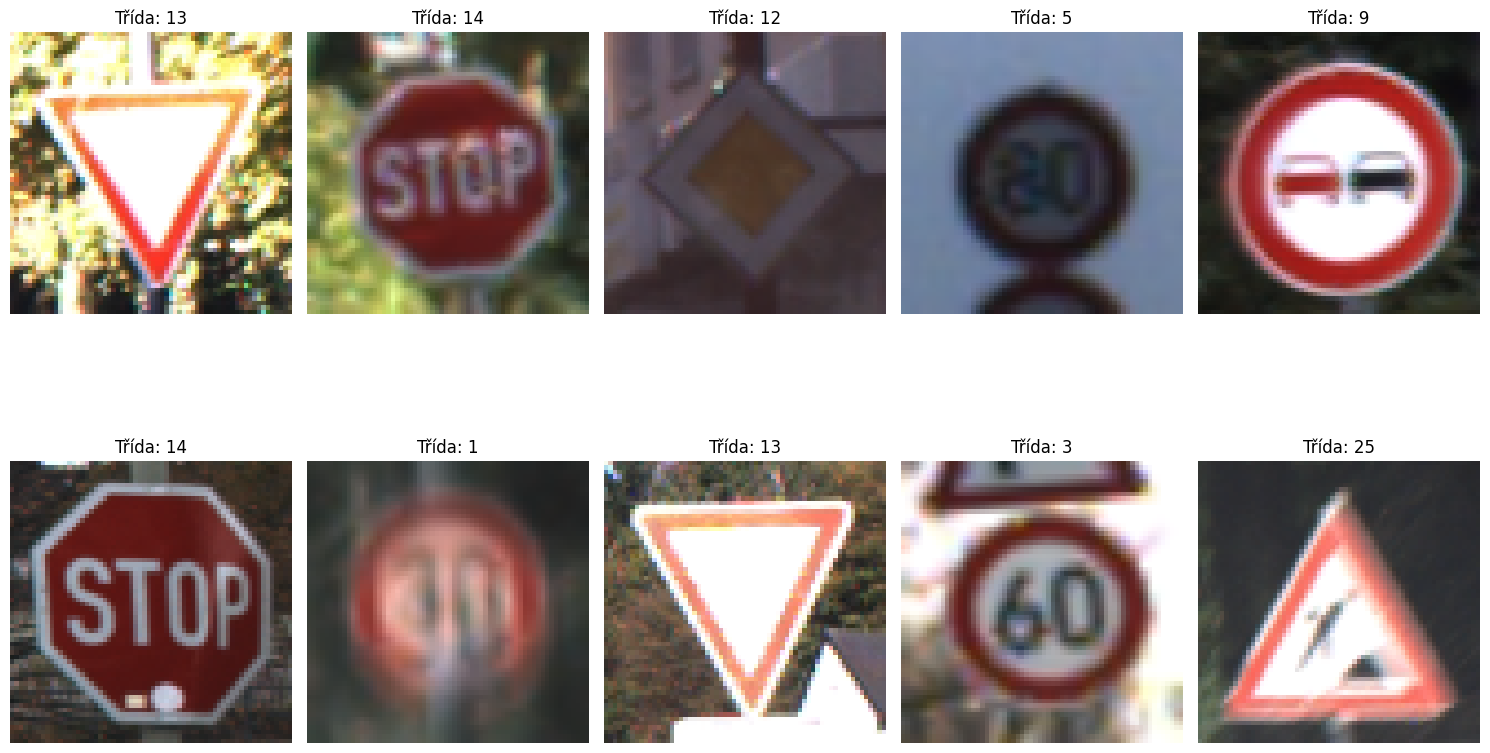

In [11]:
plt.figure(figsize=(15,10))

# náhodných 10 indexů
random_indices = np.random.choice(len(X_train_rgb), 10, replace=False)

for i, idx in enumerate(random_indices):

    img = X_train_rgb[idx].reshape(IMG_SIZE, IMG_SIZE, 3)

    plt.subplot(2,5,i+1)

    plt.imshow(img)

    plt.title(f"Třída: {y_train_rgb[idx]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

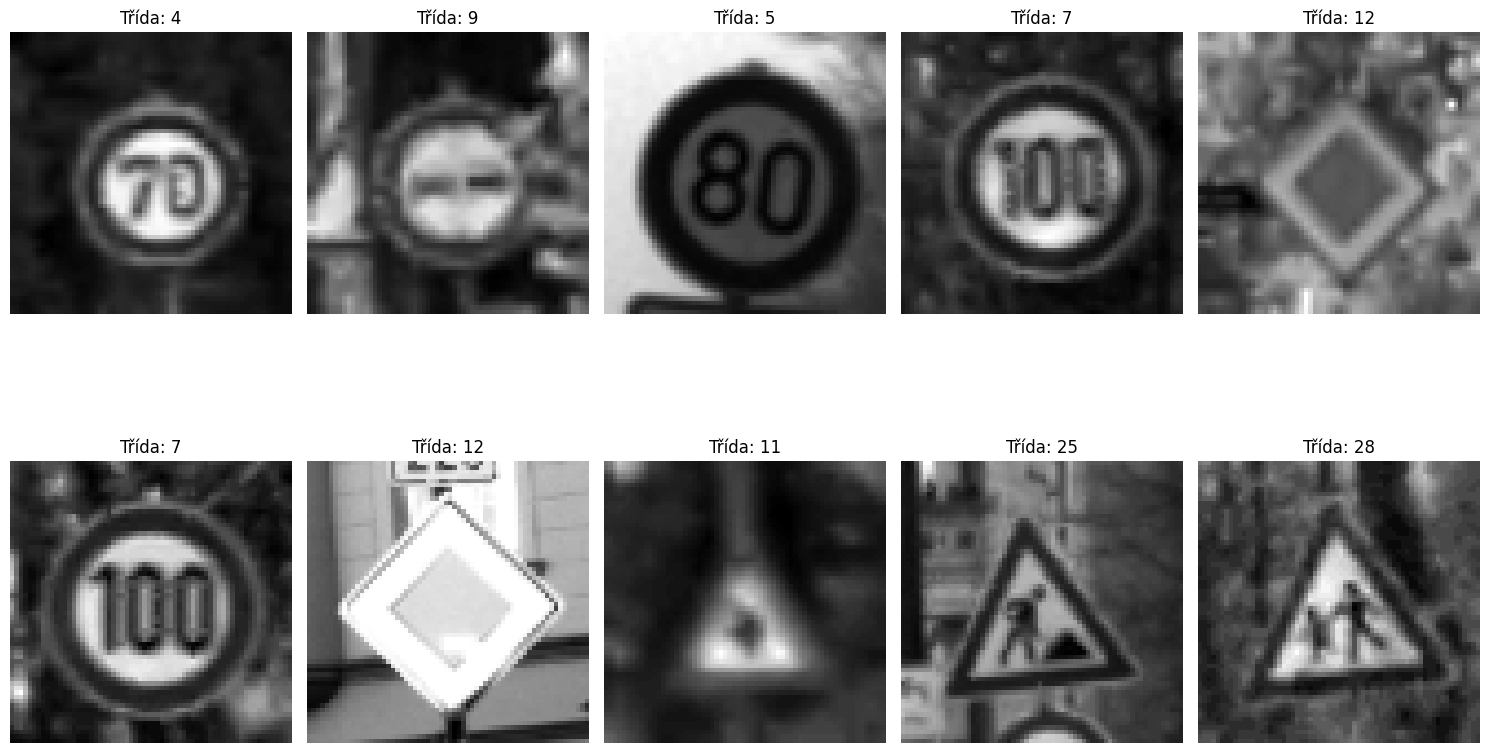

In [12]:
plt.figure(figsize=(15,10))

# náhodných 10 indexů
random_indices = np.random.choice(len(X_train_gray), 10, replace=False)

for i, idx in enumerate(random_indices):

    img = X_train_gray[idx].reshape(IMG_SIZE, IMG_SIZE)

    plt.subplot(2,5,i+1)

    plt.imshow(img, cmap="gray")

    plt.title(f"Třída: {y_train_gray[idx]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Normalizace a čištění dat
Sjednocení velikosti obrázků, vypočítám si průměr a medián jak jsou veliké, abych věděl na jakou velikost je mám sjednotit

In [13]:
widths = []
heights = []

for cls in classes:
    
    class_path = os.path.join(train_path, cls)
    
    for image_name in os.listdir(class_path):
        
        image_path = os.path.join(class_path, image_name)
        
        img = cv2.imread(image_path)
        
        h, w = img.shape[:2]
        
        widths.append(w)
        heights.append(h)

print("Průměrná šířka:", np.mean(widths))
print("Průměrná výška:", np.mean(heights))

print("Min šířka:", np.min(widths))
print("Max šířka:", np.max(widths))

print("Min výška:", np.min(heights))
print("Max výška:", np.max(heights))

print("Medián šířky:", np.median(widths))
print("Medián výšky:", np.median(heights))

Průměrná šířka: 50.83587951745773
Průměrná výška: 50.328929582493814
Min šířka: 25
Max šířka: 243
Min výška: 25
Max výška: 225
Medián šířky: 43.0
Medián výšky: 43.0


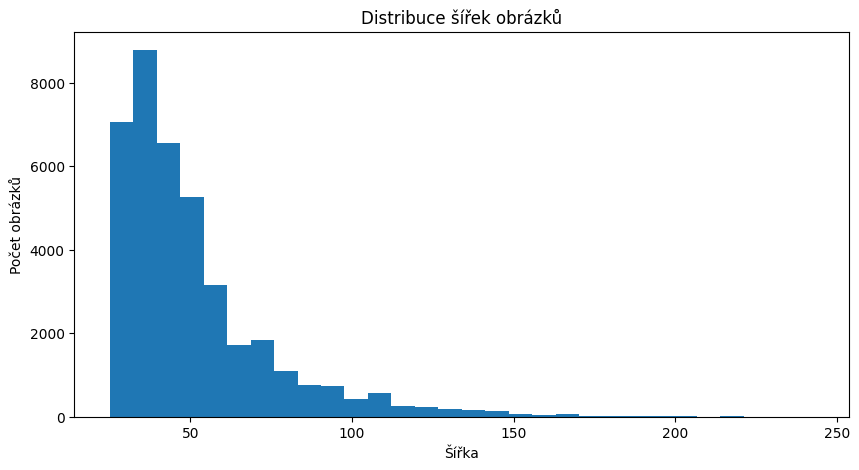

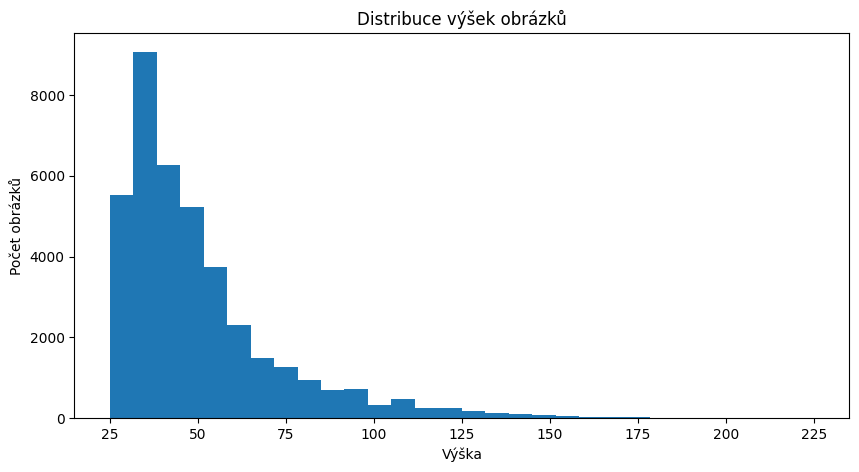

In [14]:
plt.figure(figsize=(10,5))
plt.hist(widths, bins=30)
plt.title("Distribuce šířek obrázků")
plt.xlabel("Šířka")
plt.ylabel("Počet obrázků")
plt.show()

plt.figure(figsize=(10,5))
plt.hist(heights, bins=30)
plt.title("Distribuce výšek obrázků")
plt.xlabel("Výška")
plt.ylabel("Počet obrázků")
plt.show()

# Baseline model - Logistická regrese

In [15]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# ============================================
# Trénink
# ============================================

print("Trénování modelu...")

start_train = time.time()

model.fit(X_train_rgb, y_train_rgb)

end_train = time.time()

train_time = end_train - start_train

print(f"Training time: {train_time:.2f} s")

# ============================================
# Inference
# ============================================

print("Probíhá inference...")

start_inference = time.time()

y_pred = model.predict(X_test_rgb)

end_inference = time.time()

inference_time = end_inference - start_inference

avg_inference = inference_time / len(X_test_rgb)

# ============================================
# Vyhodnocení
# ============================================

accuracy = accuracy_score(y_test_rgb, y_pred)
f1 = f1_score(y_test_rgb, y_pred, average="weighted")

print("\n===== VÝSLEDKY =====")

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Training time: {train_time:.2f} s")

print(f"Inference time celkem: {inference_time:.4f} s")

print(f"Průměrná inference na obrázek: {avg_inference*1000:.4f} ms")

# ============================================
# Classification report
# ============================================

print("\nClassification Report:")
print(classification_report(y_test_rgb, y_pred))


Trénování modelu...
Training time: 241.03 s
Probíhá inference...

===== VÝSLEDKY =====
Accuracy: 0.9575
F1 Score: 0.9575
Training time: 241.03 s
Inference time celkem: 0.1524 s
Průměrná inference na obrázek: 0.0194 ms

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.79      0.86        42
           1       0.94      0.94      0.94       444
           2       0.94      0.94      0.94       450
           3       0.93      0.89      0.91       282
           4       0.94      0.95      0.94       396
           5       0.90      0.93      0.91       372
           6       0.98      0.99      0.98        84
           7       0.96      0.96      0.96       288
           8       0.93      0.96      0.94       282
           9       0.99      0.96      0.97       294
          10       0.98      0.98      0.98       402
          11       0.98      0.94      0.96       264
          12       1.00      0.99      0.99       420
 

In [16]:
y_pred = model.predict(X_test_rgb)
y_prob = model.predict_proba(X_test_rgb)

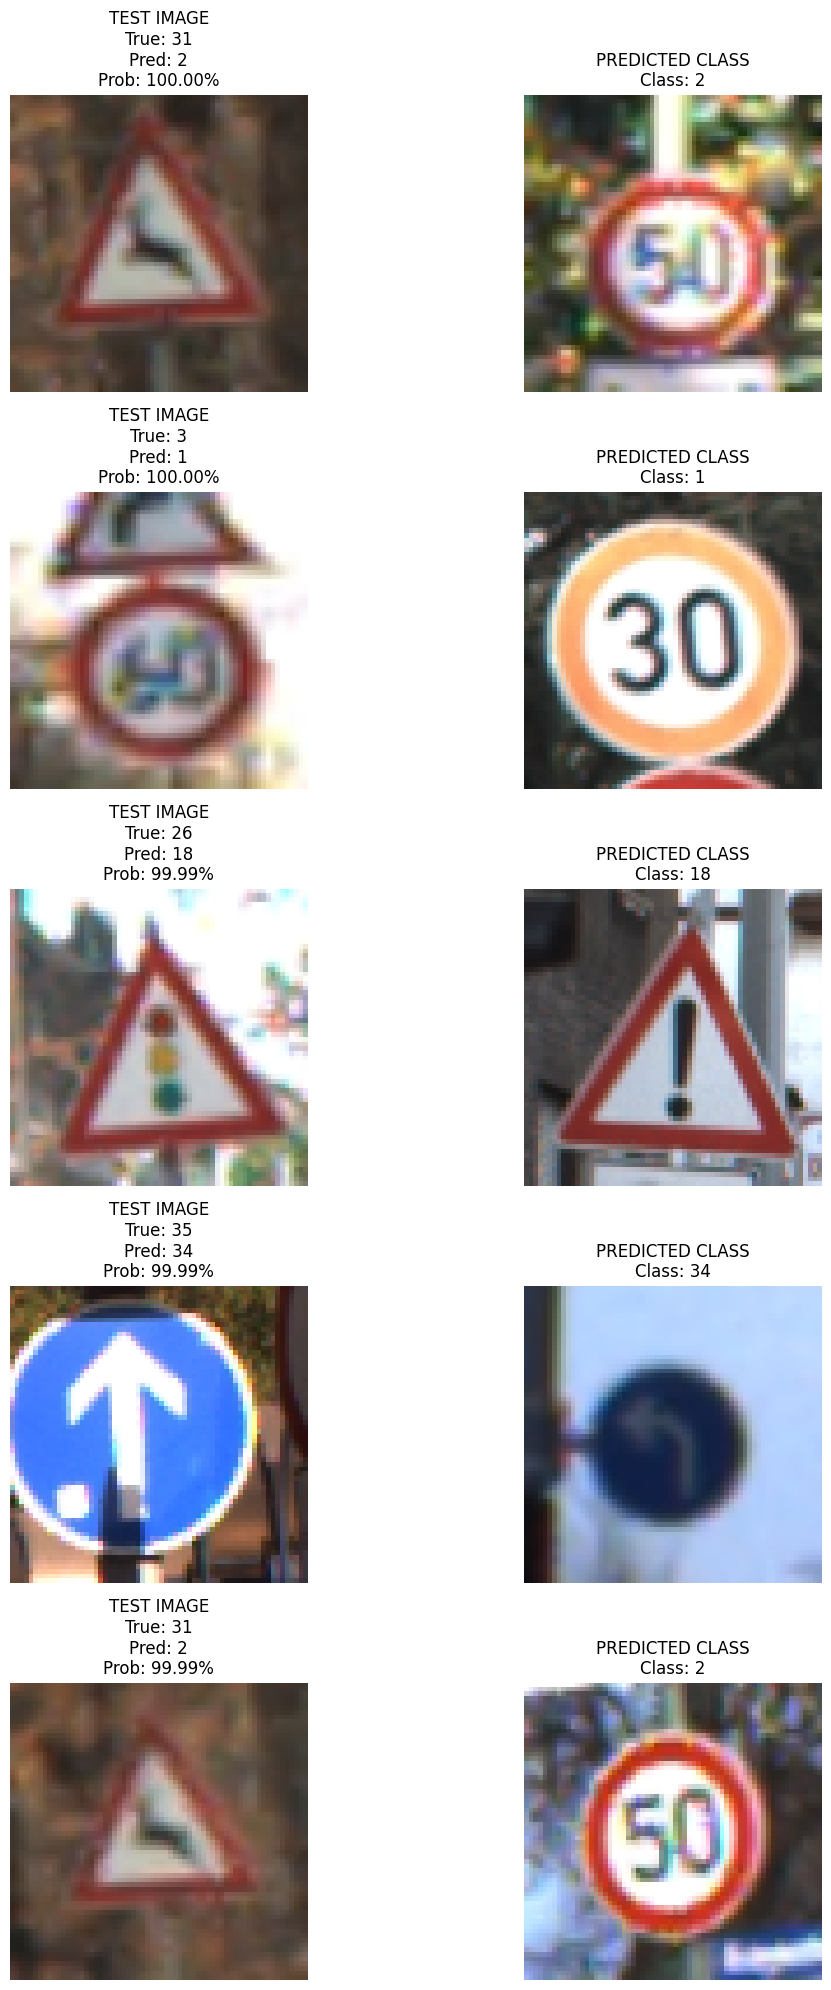

In [17]:
show_top_wrong_predictions(
    X_test_rgb,
    y_test_rgb,
    y_pred,
    y_prob,
    X_train_rgb,
    y_train_rgb,
    grayscale=False
)

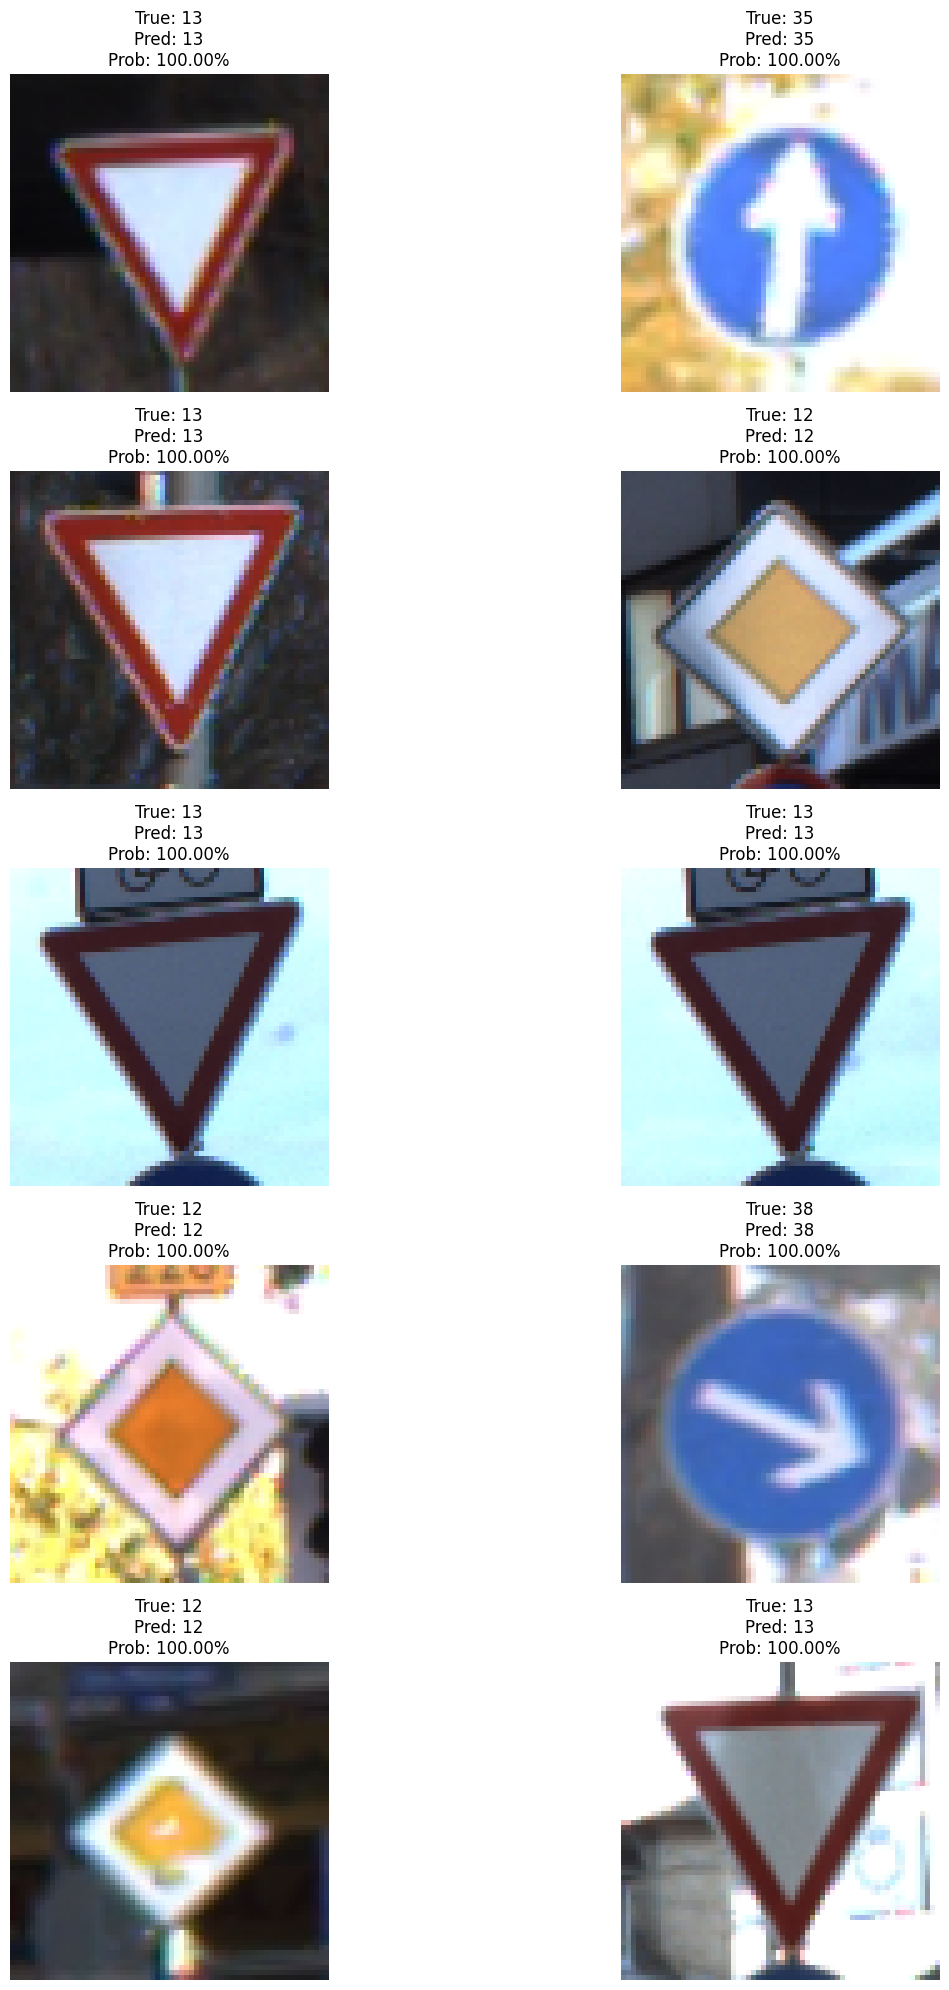

In [18]:
show_top_correct_predictions(
    X_test_rgb,
    y_test_rgb,
    y_pred,
    y_prob,
    grayscale=False
)

# 1. model, LinearSVC

In [19]:
# ============================================
# PCA
# ============================================
PCA_COMPONENTS = 500

print("\nProvádí se PCA...")

start_pca = time.time()

pca = PCA(n_components=PCA_COMPONENTS)

X_train_pca = pca.fit_transform(X_train_gray)
X_test_pca = pca.transform(X_test_gray)

end_pca = time.time()

pca_time = end_pca - start_pca

print(f"PCA hotovo za: {pca_time:.2f} s")

print("Nový shape X_train:", X_train_pca.shape)
print("Nový shape X_test:", X_test_pca.shape)

# ============================================
# Linear SVC Model
# ============================================

model = LinearSVC(
    random_state=42,
    max_iter=5000
)

# ============================================
# Trénink
# ============================================

print("\nTrénování LinearSVC modelu...")

start_train = time.time()

model.fit(X_train_pca, y_train_gray)

end_train = time.time()

train_time = end_train - start_train

print(f"Training time: {train_time:.2f} s")

# ============================================
# Inference
# ============================================

print("\nProbíhá inference...")

start_inference = time.time()

y_pred = model.predict(X_test_pca)

end_inference = time.time()

inference_time = end_inference - start_inference

avg_inference = inference_time / len(X_test_pca)

# ============================================
# Vyhodnocení
# ============================================

accuracy = accuracy_score(y_test_gray, y_pred)
f1 = f1_score(y_test_gray, y_pred, average="weighted")

print("\n===== VÝSLEDKY =====")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"PCA components: {PCA_COMPONENTS}")
print(f"Training time: {train_time:.2f} s")
print(f"Inference time celkem: {inference_time:.4f} s")
print(f"Průměrná inference na obrázek: {avg_inference*1000:.4f} ms")

# ============================================
# Classification report 
# ============================================

print("\nClassification Report:")
print(classification_report(y_test_gray, y_pred))


Provádí se PCA...
PCA hotovo za: 7.25 s
Nový shape X_train: (31367, 500)
Nový shape X_test: (7842, 500)

Trénování LinearSVC modelu...
Training time: 153.13 s

Probíhá inference...

===== VÝSLEDKY =====
Accuracy: 0.8833
F1 Score: 0.8833
PCA components: 500
Training time: 153.13 s
Inference time celkem: 0.0086 s
Průměrná inference na obrázek: 0.0011 ms

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.71      0.80        42
           1       0.86      0.85      0.86       444
           2       0.82      0.85      0.83       450
           3       0.83      0.83      0.83       282
           4       0.82      0.88      0.85       396
           5       0.81      0.76      0.78       372
           6       0.87      0.99      0.93        84
           7       0.88      0.85      0.86       288
           8       0.79      0.89      0.84       282
           9       0.97      0.87      0.92       294
          10       0.89   

# 2. model, Random Forest

### Random forest s Grayscale vstupem a základní nastavení

In [20]:
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

# ============================================
# Trénink
# ============================================

print("Trénování Random Forest modelu...")

start_train = time.time()

model.fit(X_train_gray, y_train_gray)

end_train = time.time()

train_time = end_train - start_train

print(f"Training time: {train_time:.2f} s")

# ============================================
# Inference
# ============================================

print("Probíhá inference...")

start_inference = time.time()

y_pred = model.predict(X_test_gray)

end_inference = time.time()

inference_time = end_inference - start_inference

avg_inference = inference_time / len(X_test_gray)

# ============================================
# Vyhodnocení
# ============================================

accuracy = accuracy_score(y_test_gray, y_pred)
f1 = f1_score(y_test_gray, y_pred, average="weighted")

print("\n===== VÝSLEDKY =====")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Training time: {train_time:.2f} s")
print(f"Inference time celkem: {inference_time:.4f} s")
print(f"Průměrná inference na obrázek: {avg_inference*1000:.4f} ms")

Trénování Random Forest modelu...
Training time: 8.93 s
Probíhá inference...

===== VÝSLEDKY =====
Accuracy: 0.9765
F1 Score: 0.9765
Training time: 8.93 s
Inference time celkem: 0.1631 s
Průměrná inference na obrázek: 0.0208 ms


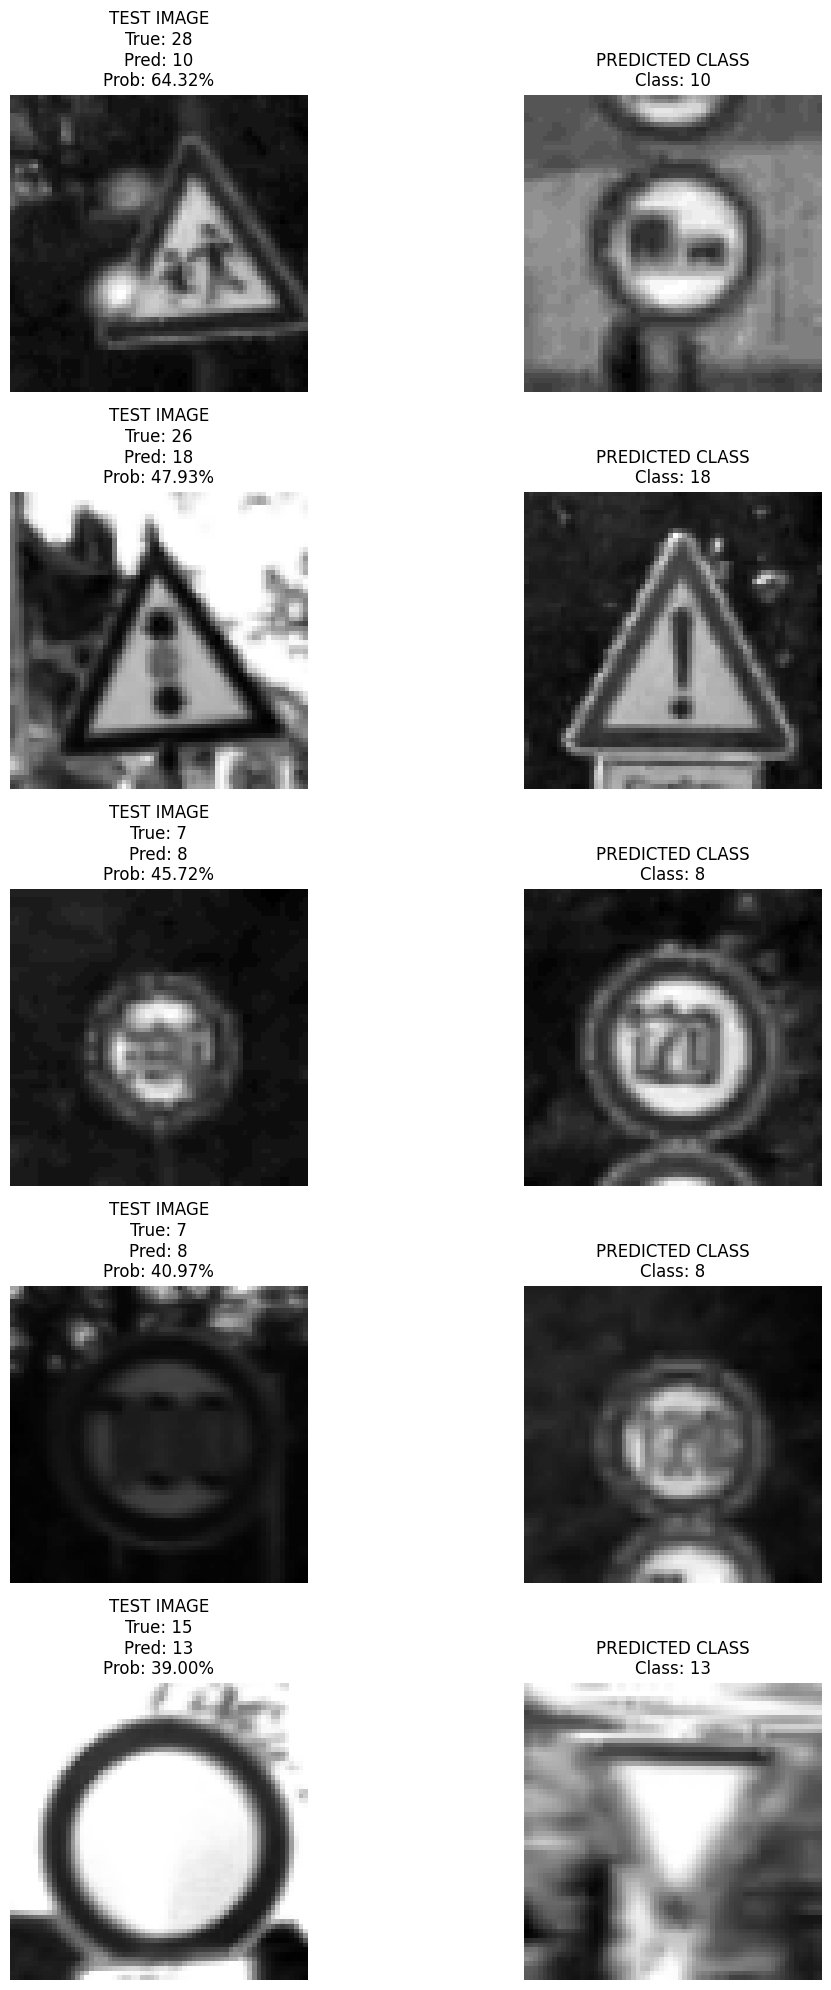

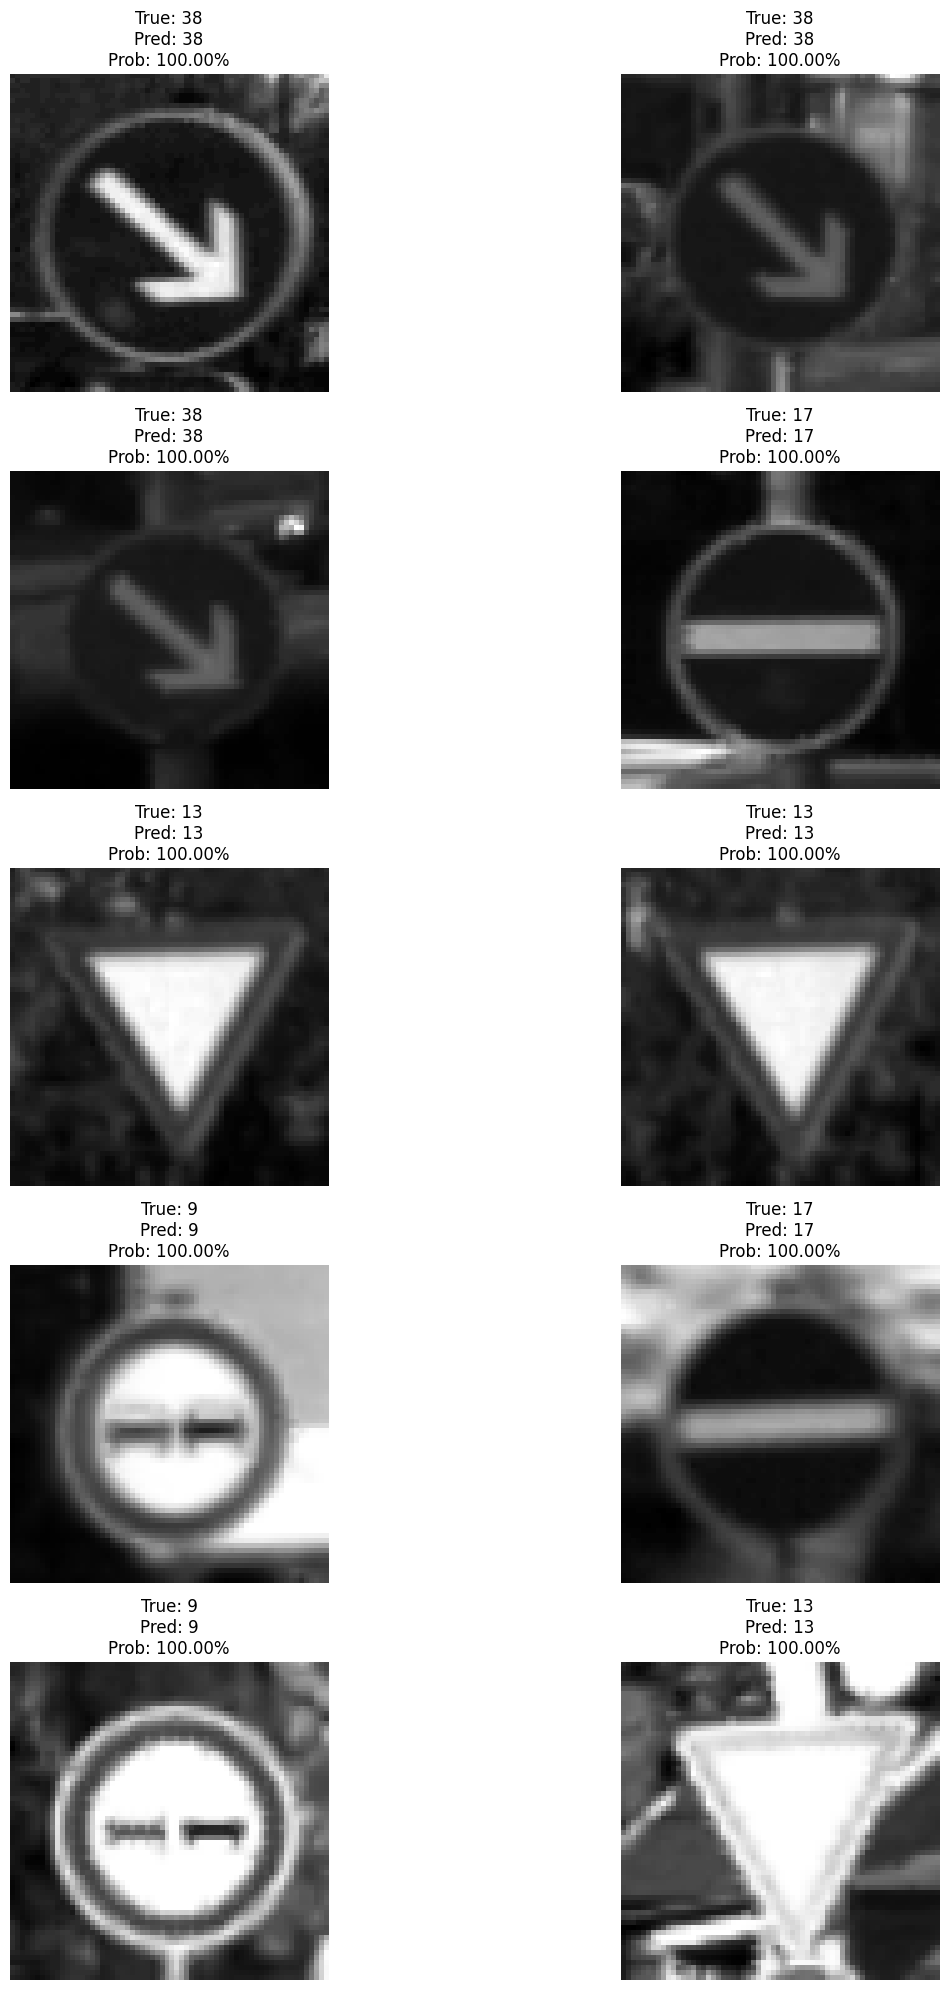

In [21]:
y_pred = model.predict(X_test_gray)
y_prob = model.predict_proba(X_test_gray)
show_top_wrong_predictions(
    X_test_gray,
    y_test_gray,
    y_pred,
    y_prob,
    X_train_gray,
    y_train_gray,
    grayscale=True
)
show_top_correct_predictions(
    X_test_gray,
    y_test_gray,
    y_pred,
    y_prob,
    grayscale=True
)

### Random forest s RGB vstupem a základní nastavení

In [22]:
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

# ============================================
# Trénink
# ============================================

print("Trénování Random Forest modelu...")

start_train = time.time()

model.fit(X_train_rgb, y_train_rgb)

end_train = time.time()

train_time = end_train - start_train

print(f"Training time: {train_time:.2f} s")

# ============================================
# Inference
# ============================================

print("Probíhá inference...")

start_inference = time.time()

y_pred = model.predict(X_test_rgb)

end_inference = time.time()

inference_time = end_inference - start_inference

avg_inference = inference_time / len(X_test_rgb)

# ============================================
# Vyhodnocení
# ============================================

accuracy = accuracy_score(y_test_rgb, y_pred)
f1 = f1_score(y_test_rgb, y_pred, average="weighted")

print("\n===== VÝSLEDKY =====")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Training time: {train_time:.2f} s")
print(f"Inference time celkem: {inference_time:.4f} s")
print(f"Průměrná inference na obrázek: {avg_inference*1000:.4f} ms")

Trénování Random Forest modelu...
Training time: 15.60 s
Probíhá inference...

===== VÝSLEDKY =====
Accuracy: 0.9768
F1 Score: 0.9768
Training time: 15.60 s
Inference time celkem: 0.2883 s
Průměrná inference na obrázek: 0.0368 ms


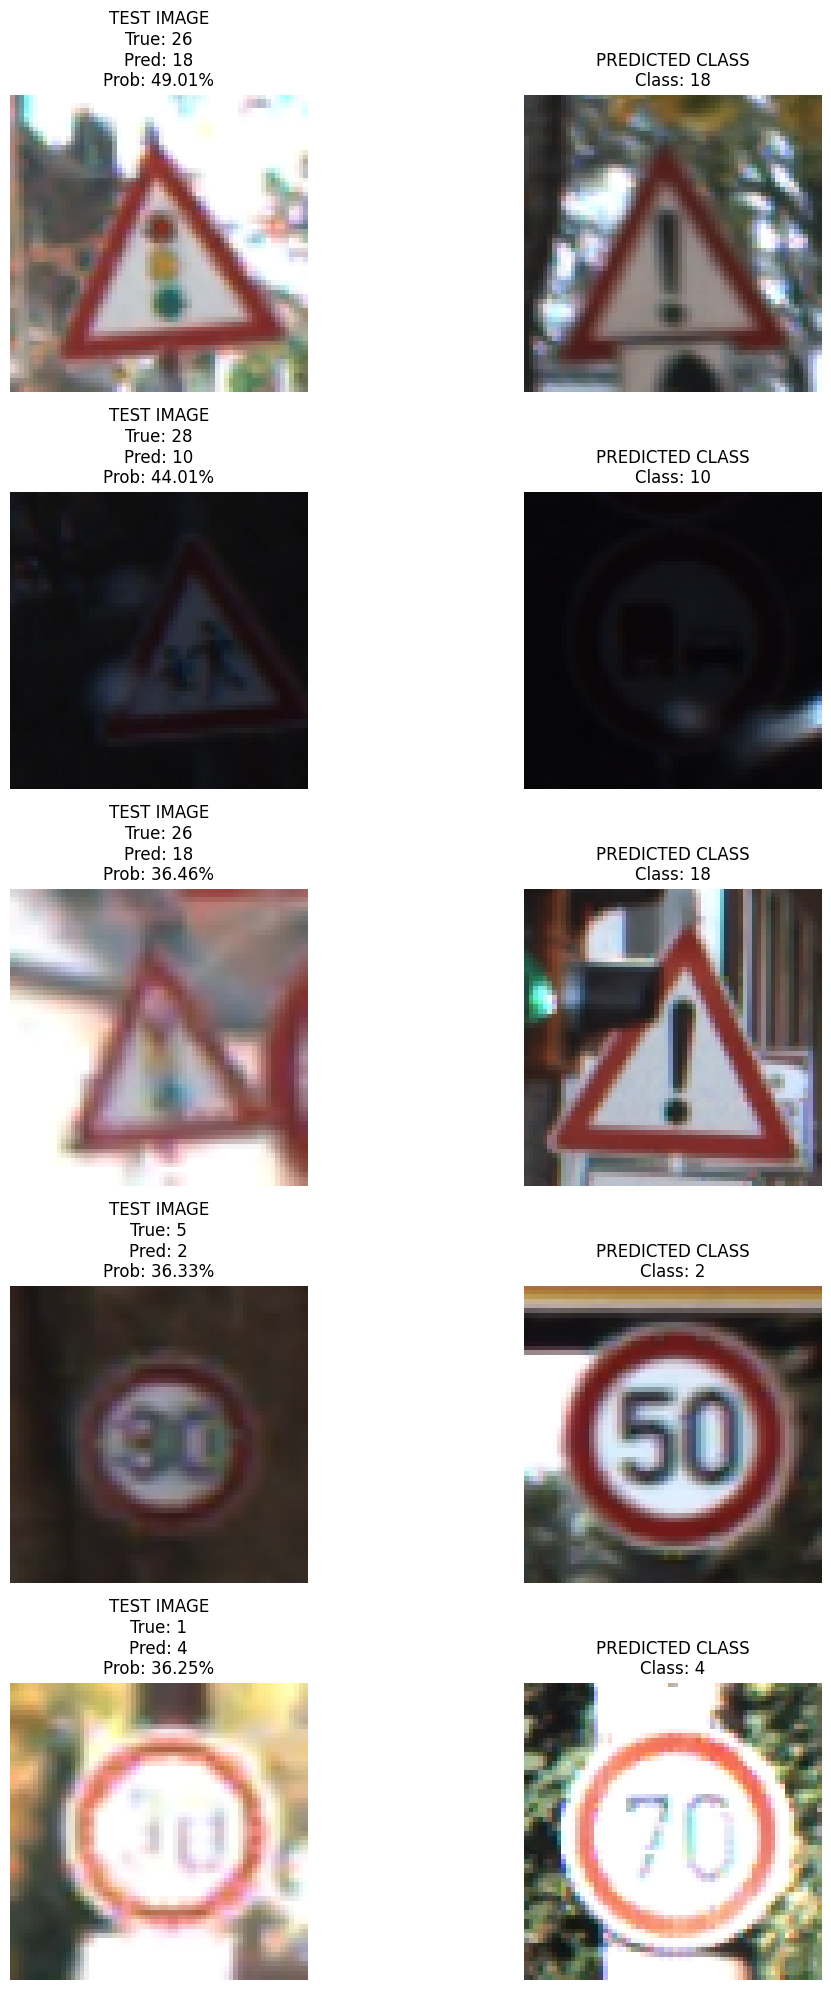

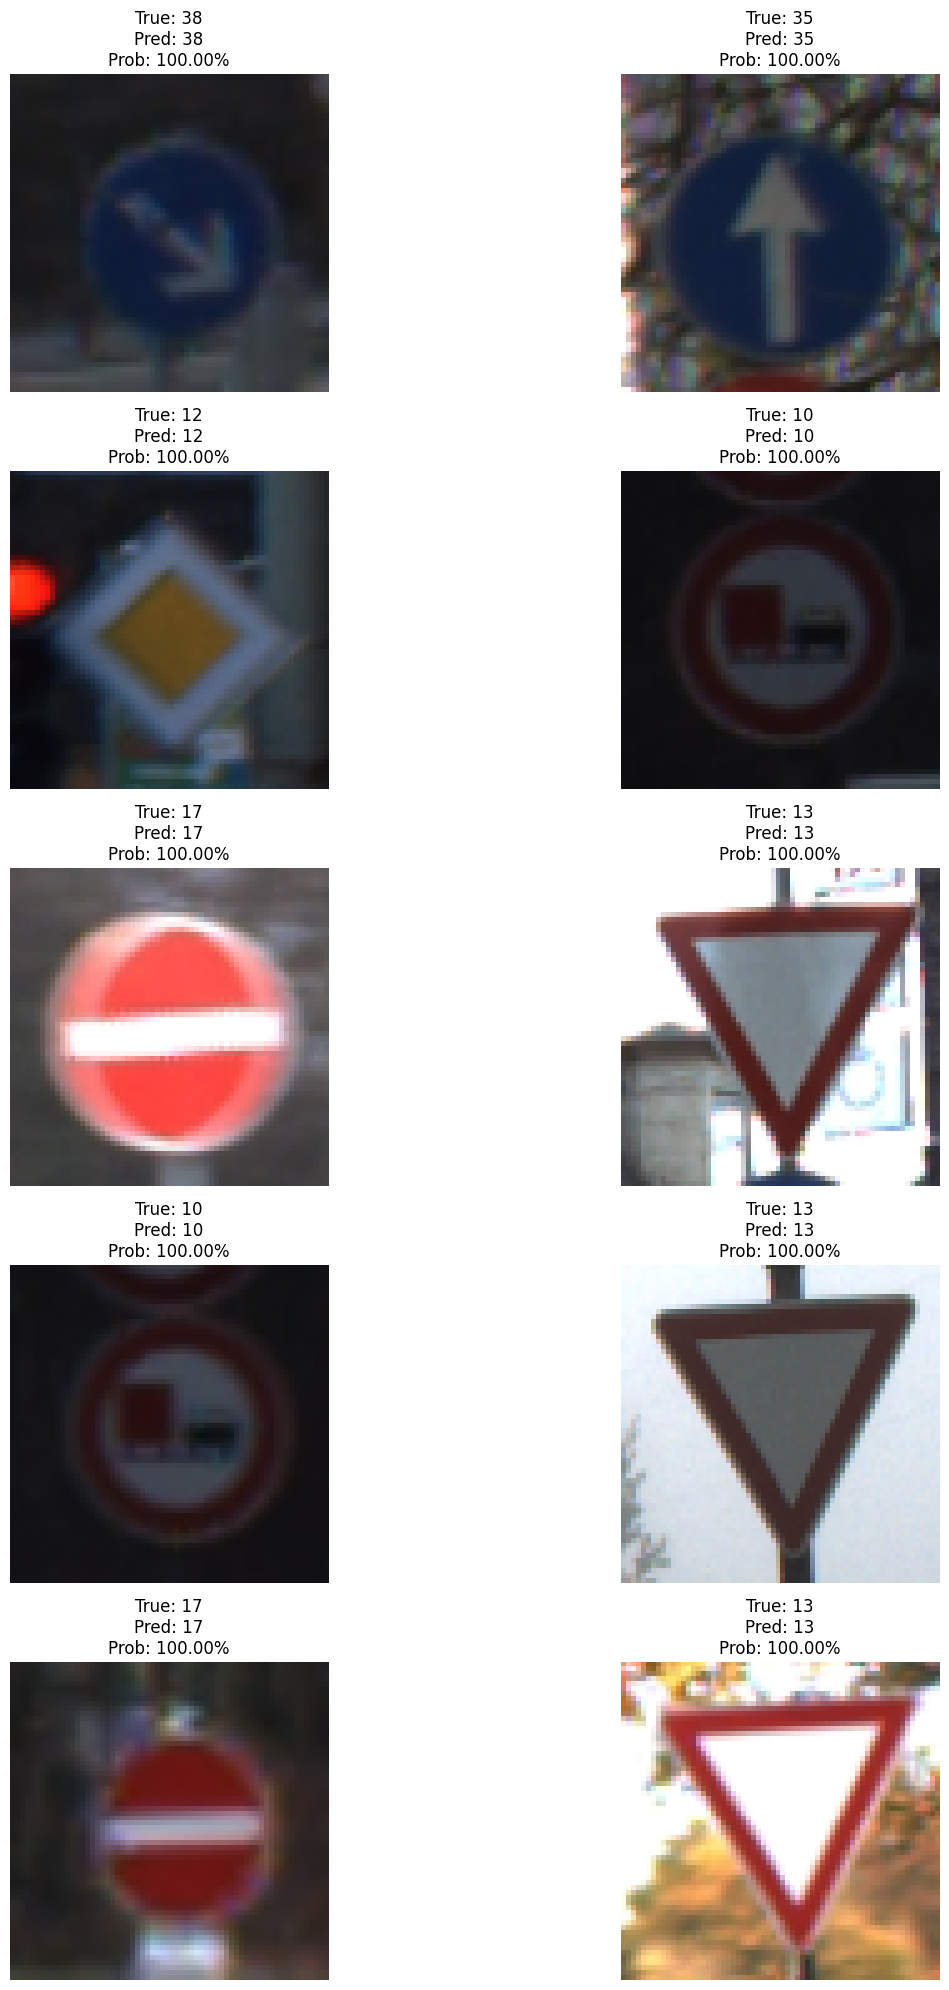

In [23]:
y_pred = model.predict(X_test_rgb)
y_prob = model.predict_proba(X_test_rgb)
show_top_wrong_predictions(
    X_test_rgb,
    y_test_rgb,
    y_pred,
    y_prob,
    X_train_rgb,
    y_train_rgb,
    grayscale=False
)
show_top_correct_predictions(
    X_test_rgb,
    y_test_rgb,
    y_pred,
    y_prob,
    grayscale=False
)

# 3. model, K-Nearest Neighbors s grayscale vstupem

In [24]:
model = KNeighborsClassifier(
    n_neighbors=5,
    weights="distance",
    n_jobs=-1
)

# ============================================
# Trénink
# ============================================

print("Trénování KNN modelu...")

start_train = time.time()

model.fit(X_train_gray, y_train_gray)

end_train = time.time()

train_time = end_train - start_train

print(f"Training time: {train_time:.2f} s")

# ============================================
# Inference
# ============================================

print("Probíhá inference...")

start_inference = time.time()

y_pred = model.predict(X_test_gray)

end_inference = time.time()

inference_time = end_inference - start_inference

avg_inference = inference_time / len(X_test_gray)

# ============================================
# Vyhodnocení
# ============================================

accuracy = accuracy_score(y_test_gray, y_pred)
f1 = f1_score(y_test_gray, y_pred, average="weighted")

print("\n===== VÝSLEDKY =====")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Training time: {train_time:.2f} s")
print(f"Inference time celkem: {inference_time:.4f} s")
print(f"Průměrná inference na obrázek: {avg_inference*1000:.4f} ms")

# ============================================
# Classification report
# ============================================

print("\nClassification Report:")
print(classification_report(y_test_gray, y_pred))


Trénování KNN modelu...
Training time: 0.11 s
Probíhá inference...

===== VÝSLEDKY =====
Accuracy: 0.8685
F1 Score: 0.8692
Training time: 0.11 s
Inference time celkem: 6.7729 s
Průměrná inference na obrázek: 0.8637 ms

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.81      0.85        42
           1       0.87      0.89      0.88       444
           2       0.84      0.85      0.84       450
           3       0.80      0.80      0.80       282
           4       0.87      0.85      0.86       396
           5       0.75      0.84      0.79       372
           6       0.96      0.93      0.95        84
           7       0.79      0.86      0.83       288
           8       0.73      0.91      0.81       282
           9       0.93      0.88      0.91       294
          10       0.87      0.91      0.89       402
          11       0.94      0.83      0.88       264
          12       0.92      0.81      0.86       420
 

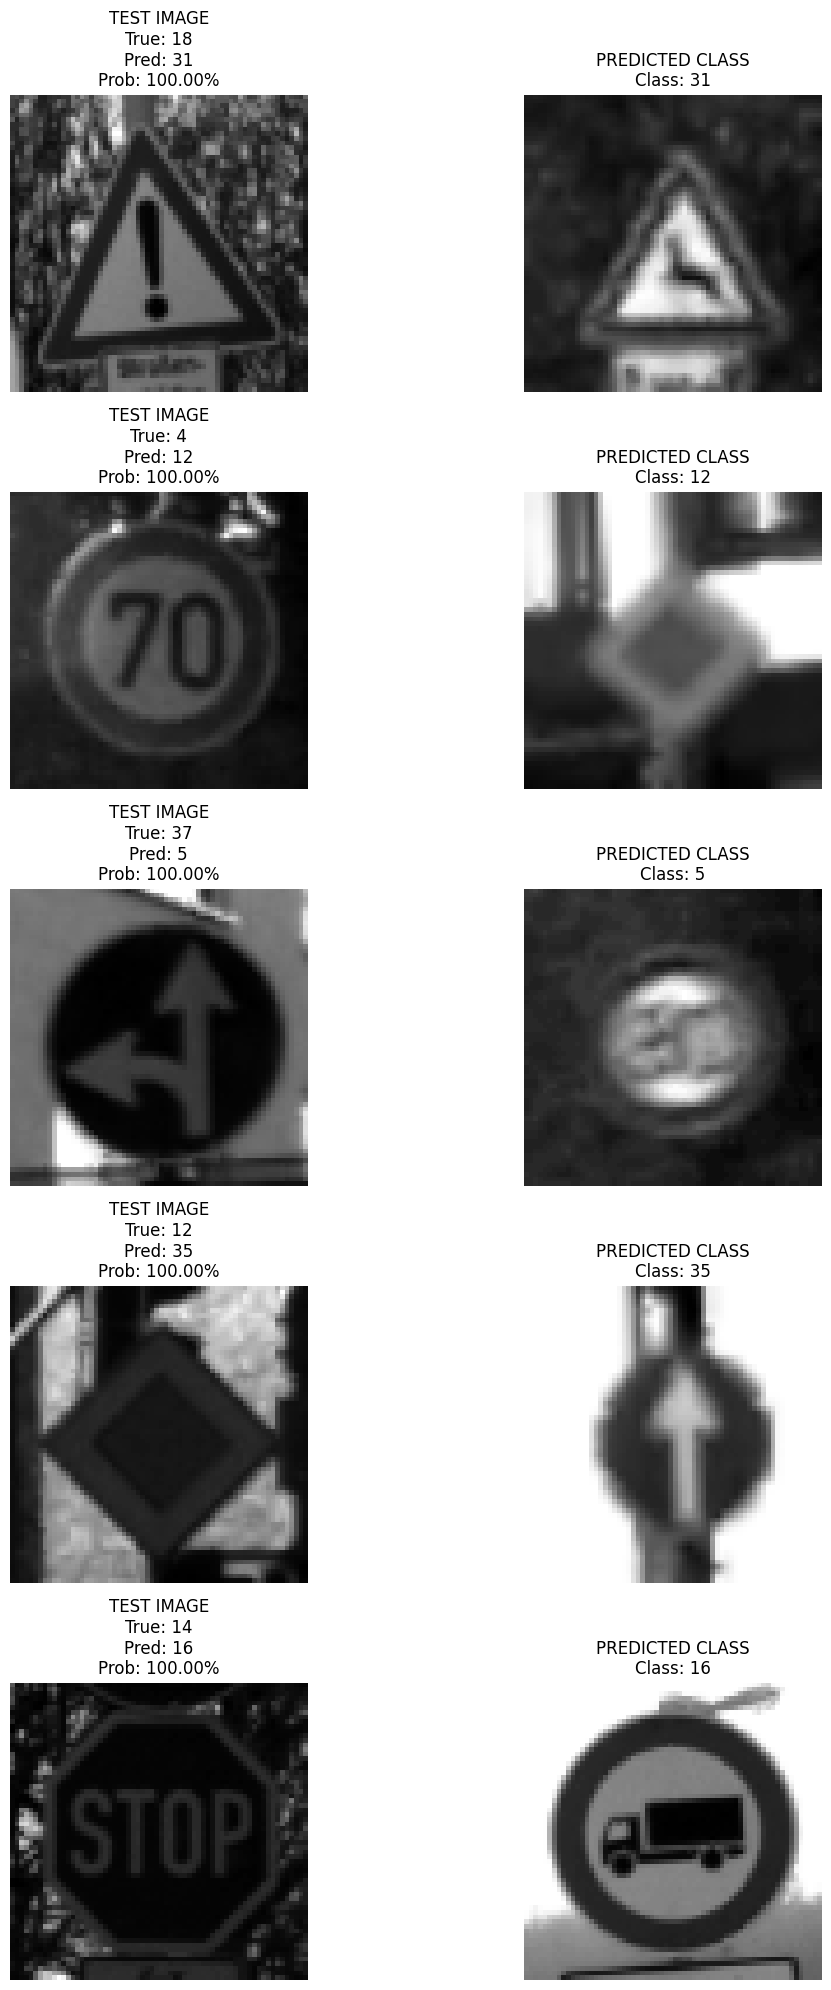

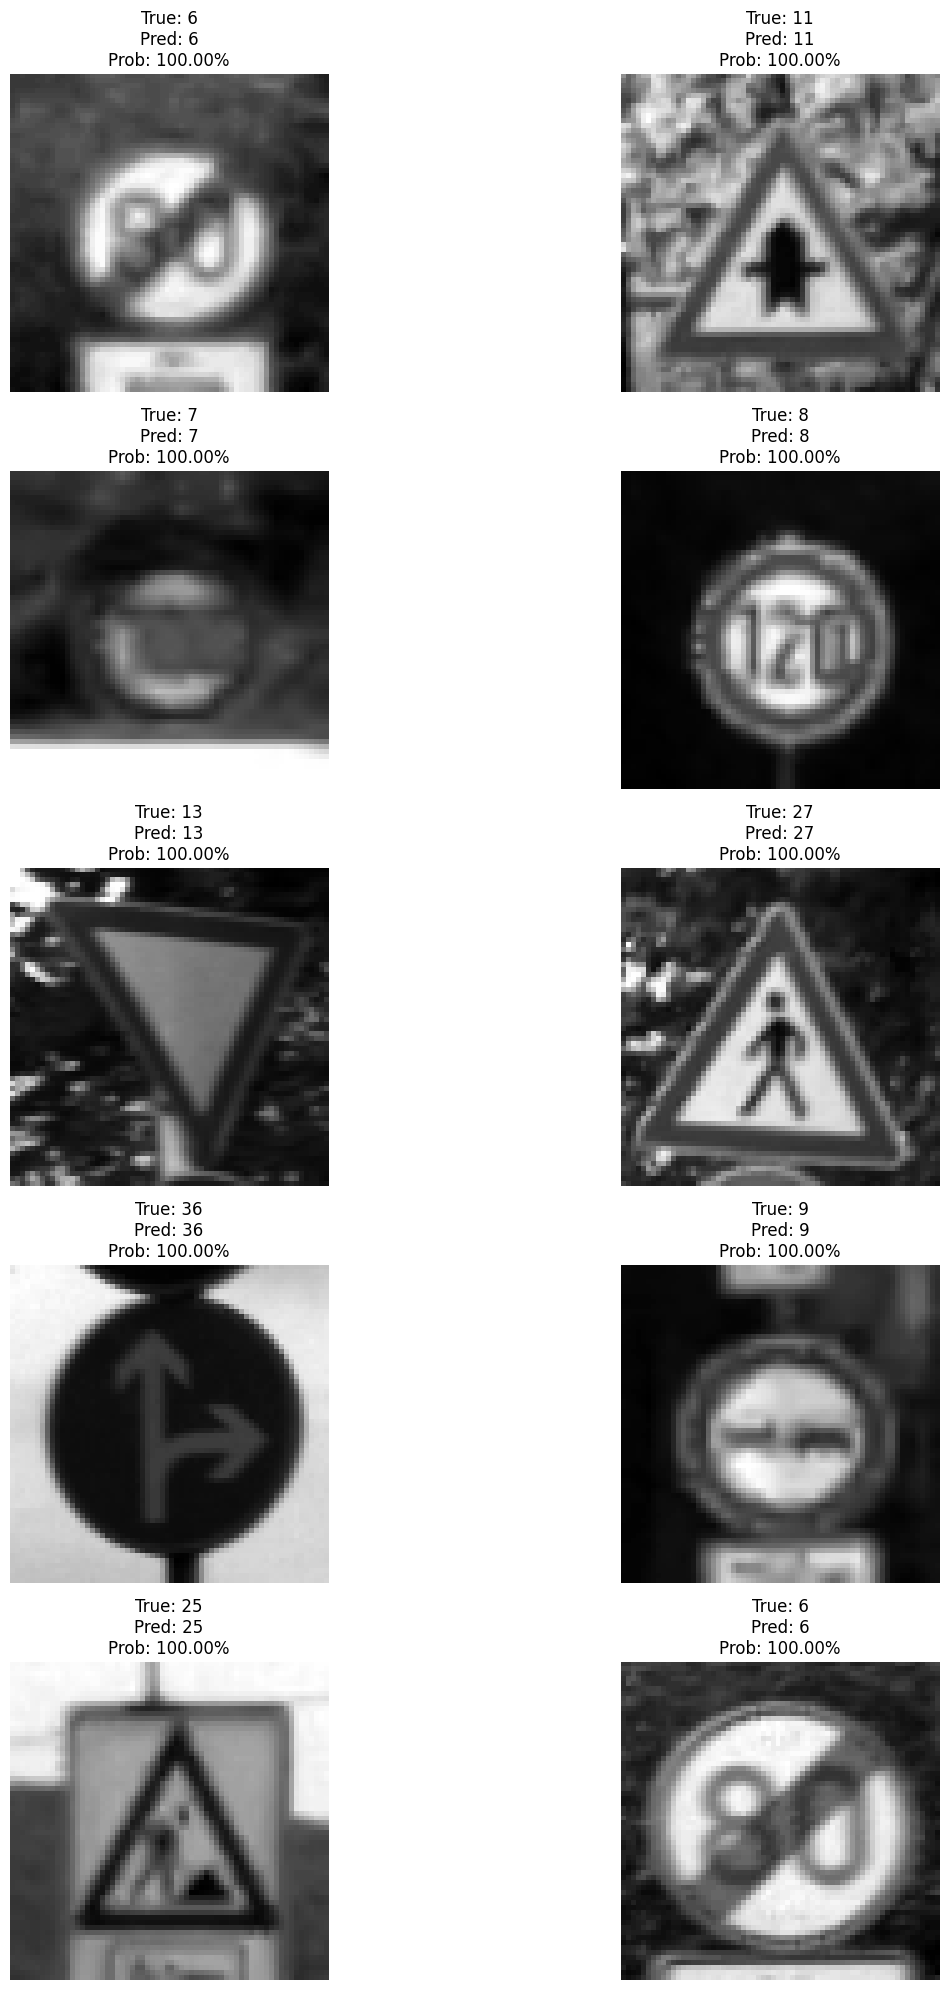

In [25]:
y_pred = model.predict(X_test_gray)
y_prob = model.predict_proba(X_test_gray)
show_top_wrong_predictions(
    X_test_gray,
    y_test_gray,
    y_pred,
    y_prob,
    X_train_gray,
    y_train_gray,
    grayscale=True
)
show_top_correct_predictions(
    X_test_gray,
    y_test_gray,
    y_pred,
    y_prob,
    grayscale=True
)

# 4. model, Decision Tree s Grayscale vstupem

In [26]:
model = DecisionTreeClassifier(
    max_depth=20,
    min_samples_split=10,
    random_state=42
)

# ============================================
# Trénink
# ============================================

print("Trénování Decision Tree modelu...")

start_train = time.time()

model.fit(X_train_gray, y_train_gray)

end_train = time.time()

train_time = end_train - start_train

print(f"Training time: {train_time:.2f} s")

# ============================================
# Inference
# ============================================

print("Probíhá inference...")

start_inference = time.time()

y_pred = model.predict(X_test_gray)

end_inference = time.time()

inference_time = end_inference - start_inference

avg_inference = inference_time / len(X_test_gray)

# ============================================
# Vyhodnocení
# ============================================

accuracy = accuracy_score(y_test_gray, y_pred)
f1 = f1_score(y_test_gray, y_pred, average="weighted")

print("\n===== VÝSLEDKY =====")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Training time: {train_time:.2f} s")
print(f"Inference time celkem: {inference_time:.4f} s")
print(f"Průměrná inference na obrázek: {avg_inference*1000:.4f} ms")

# ============================================
# Classification report
# ============================================

print("\nClassification Report:")
print(classification_report(y_test_gray, y_pred))


Trénování Decision Tree modelu...
Training time: 114.93 s
Probíhá inference...

===== VÝSLEDKY =====
Accuracy: 0.7297
F1 Score: 0.7305
Training time: 114.93 s
Inference time celkem: 0.0658 s
Průměrná inference na obrázek: 0.0084 ms

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.60      0.62        42
           1       0.61      0.71      0.66       444
           2       0.63      0.73      0.68       450
           3       0.60      0.66      0.63       282
           4       0.76      0.70      0.73       396
           5       0.51      0.62      0.56       372
           6       0.80      0.62      0.70        84
           7       0.68      0.64      0.66       288
           8       0.59      0.65      0.62       282
           9       0.81      0.83      0.82       294
          10       0.89      0.89      0.89       402
          11       0.86      0.80      0.83       264
          12       0.79      0.80      0.

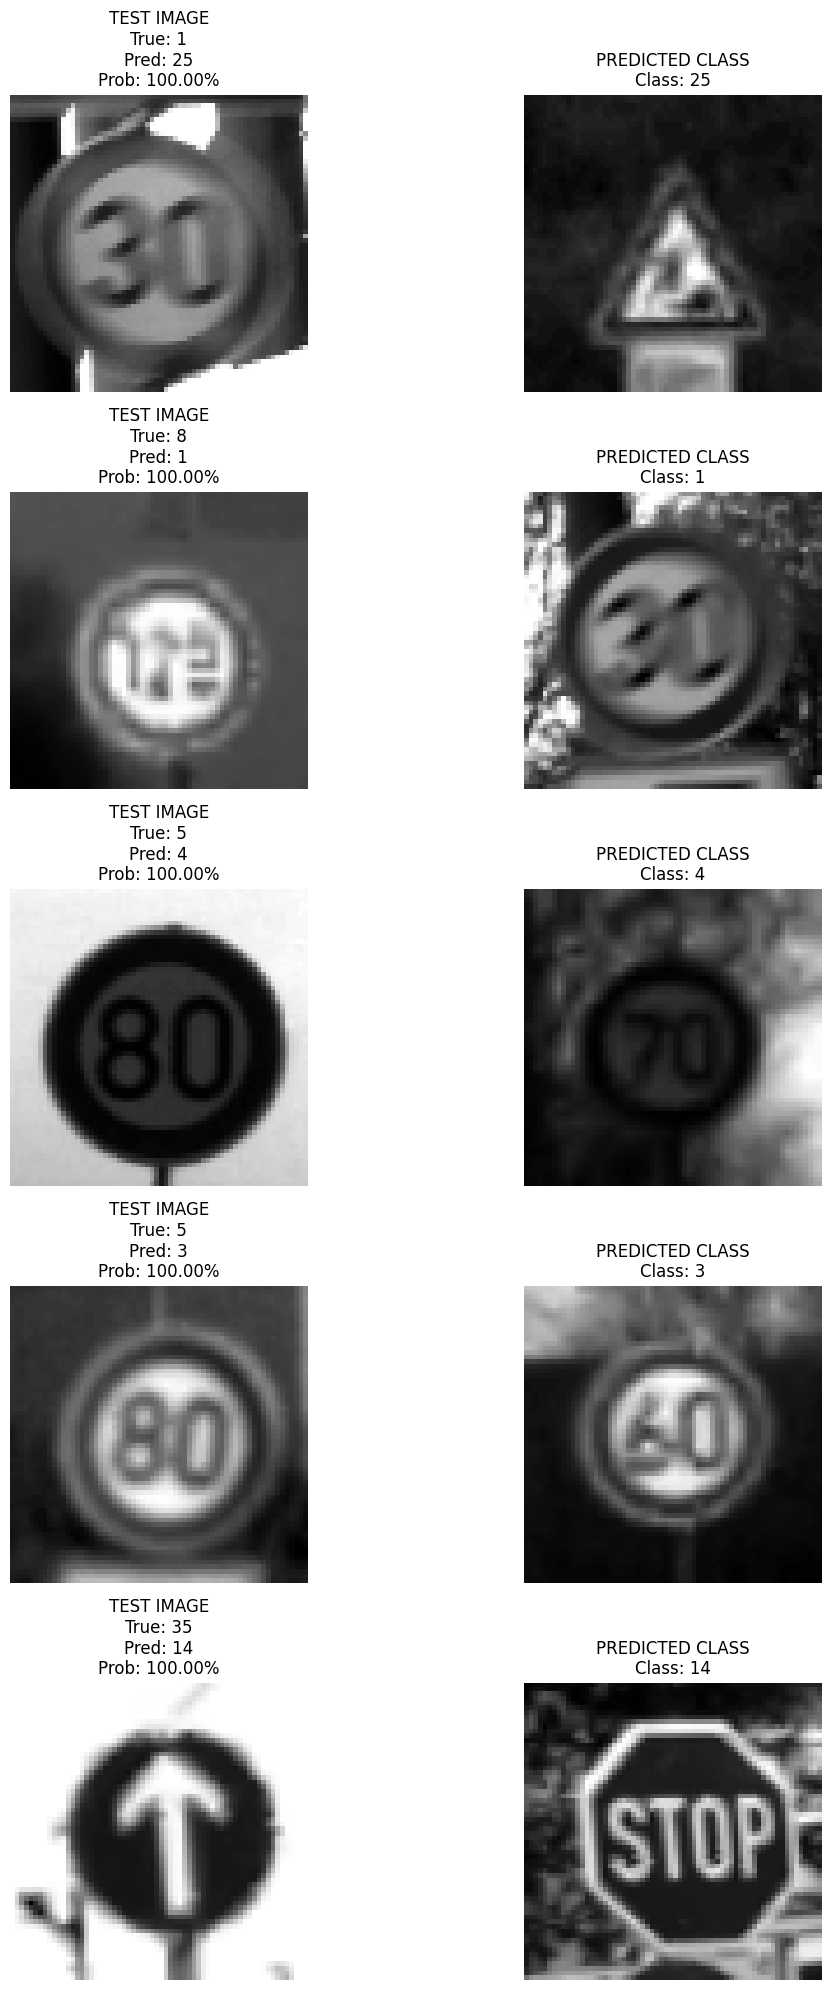

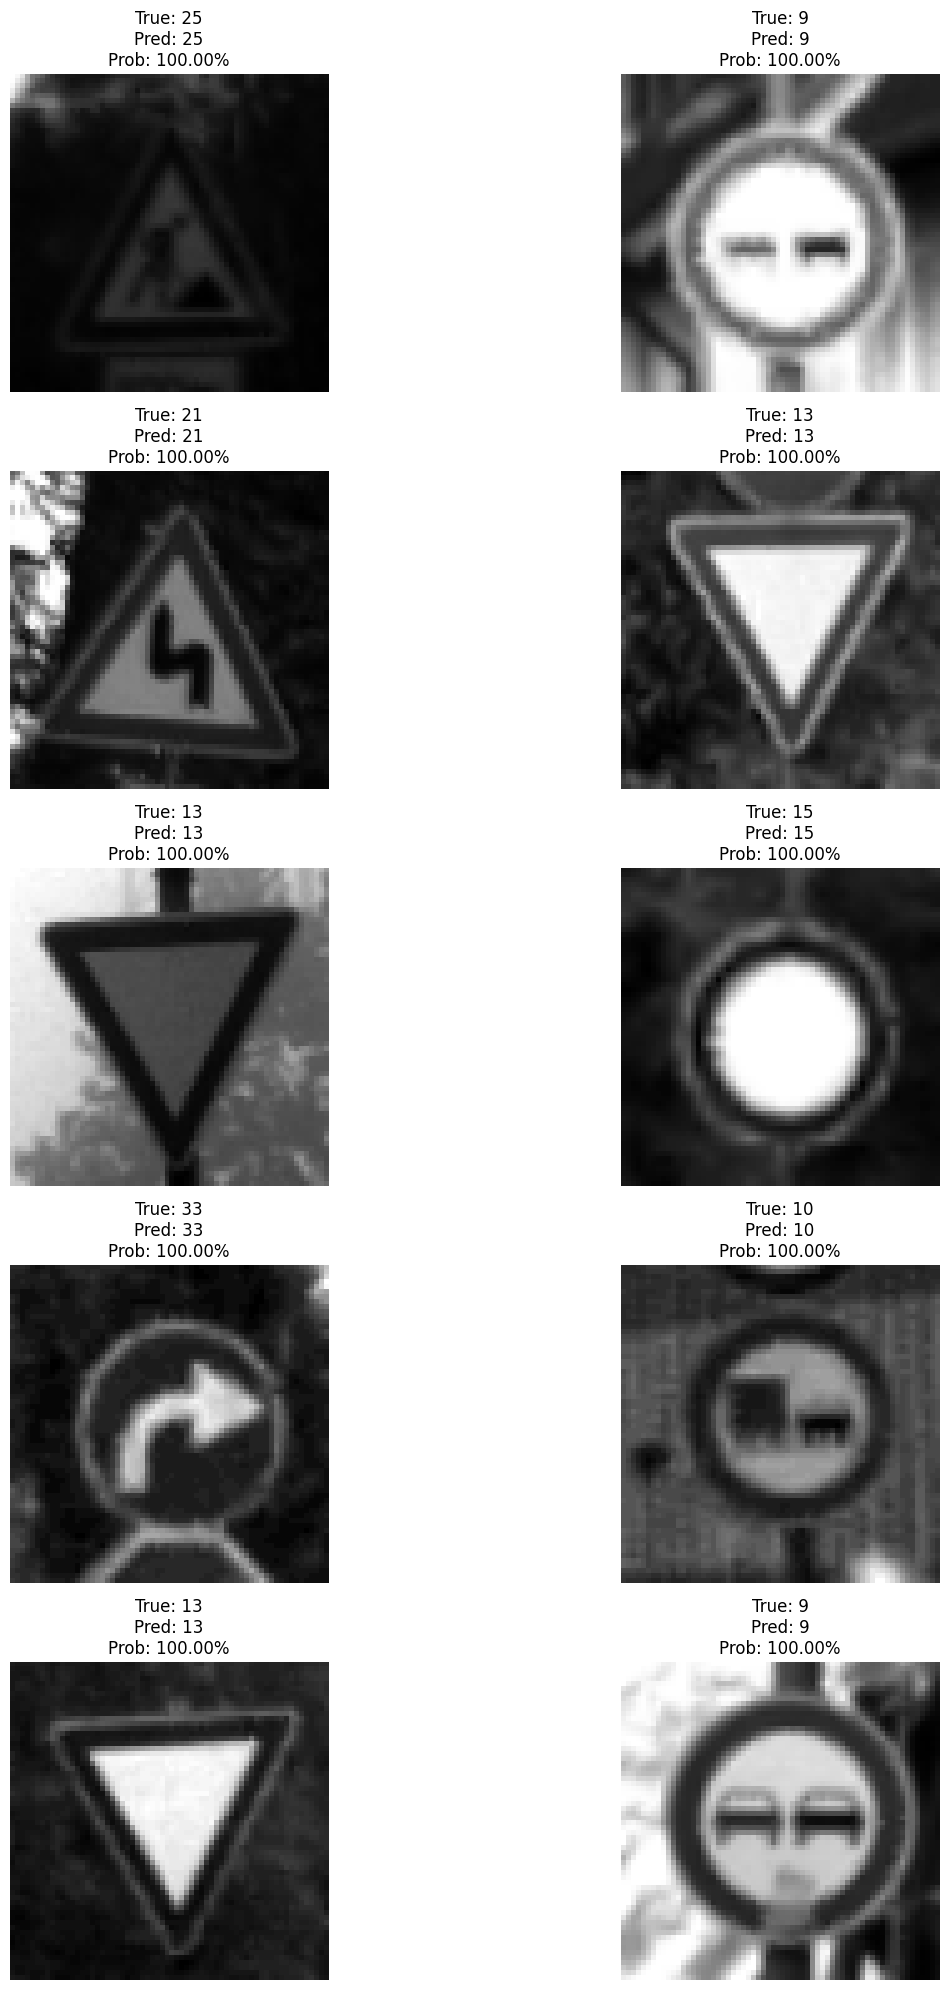

In [27]:
y_pred = model.predict(X_test_gray)
y_prob = model.predict_proba(X_test_gray)
show_top_wrong_predictions(
    X_test_gray,
    y_test_gray,
    y_pred,
    y_prob,
    X_train_gray,
    y_train_gray,
    grayscale=True
)
show_top_correct_predictions(
    X_test_gray,
    y_test_gray,
    y_pred,
    y_prob,
    grayscale=True
)

# Tuning modelu Random Forest s Grayscale vstupem

Toto trvá okolo 10 minut než celé proběhne.

In [28]:
# kombinace parametrů
n_estimators_list = [100, 200, 300]
max_depth_list = [20, 30, None]
min_samples_split_list = [2, 5, 10]

results = []

best_model = None
best_accuracy = 0
best_result = None

print("\nZačíná tuning Random Forest...\n")

for n_estimators in n_estimators_list:
    for max_depth in max_depth_list:
        for min_samples_split in min_samples_split_list:

            print(f"Testuji:")
            print(f"n_estimators={n_estimators}")
            print(f"max_depth={max_depth}")
            print(f"min_samples_split={min_samples_split}")

            # model
            model = RandomForestClassifier(
                n_estimators=n_estimators,
                max_depth=max_depth,
                min_samples_split=min_samples_split,
                random_state=42,
                n_jobs=-1
            )

            # ============================================
            # Trénink
            # ============================================

            start_train = time.time()

            model.fit(X_train_gray, y_train_gray)

            end_train = time.time()

            train_time = end_train - start_train

            # ============================================
            # Inference
            # ============================================

            start_inference = time.time()

            y_pred = model.predict(X_test_gray)

            end_inference = time.time()

            inference_time = end_inference - start_inference
            avg_inference = inference_time / len(X_test_gray)

            # ============================================
            # Metriky
            # ============================================

            accuracy = accuracy_score(y_test_gray, y_pred)
            f1 = f1_score(y_test_gray, y_pred, average="weighted")

            print(f"Accuracy: {accuracy:.4f}")
            print(f"F1 Score: {f1:.4f}")
            print(f"Training time: {train_time:.2f} s")
            print(f"Inference time: {inference_time:.4f} s")
            print("-" * 40)

            # uložení výsledků
            result = {
                "n_estimators": n_estimators,
                "max_depth": max_depth,
                "min_samples_split": min_samples_split,
                "accuracy": accuracy,
                "f1": f1,
                "train_time": train_time,
                "inference_time": inference_time
            }

            results.append(result)

            # nejlepší model
            if accuracy > best_accuracy:
                best_accuracy = accuracy
                best_model = model
                best_result = result

# ============================================
# Výsledky
# ============================================

print("\n===== VŠECHNY VÝSLEDKY =====")

for result in results:
    print(result)

print("\n===== NEJLEPŠÍ MODEL =====")
print(f"Best Accuracy: {best_result['accuracy']:.4f}")
print(f"Best F1 Score: {best_result['f1']:.4f}")
print(f"n_estimators: {best_result['n_estimators']}")
print(f"max_depth: {best_result['max_depth']}")
print(f"min_samples_split: {best_result['min_samples_split']}")
print(f"Training time: {best_result['train_time']:.2f} s")
print(f"Inference time: {best_result['inference_time']:.4f} s")


Začíná tuning Random Forest...

Testuji:
n_estimators=100
max_depth=20
min_samples_split=2
Accuracy: 0.9765
F1 Score: 0.9765
Training time: 9.22 s
Inference time: 0.1470 s
----------------------------------------
Testuji:
n_estimators=100
max_depth=20
min_samples_split=5
Accuracy: 0.9758
F1 Score: 0.9757
Training time: 9.50 s
Inference time: 0.1441 s
----------------------------------------
Testuji:
n_estimators=100
max_depth=20
min_samples_split=10
Accuracy: 0.9741
F1 Score: 0.9741
Training time: 8.91 s
Inference time: 0.1479 s
----------------------------------------
Testuji:
n_estimators=100
max_depth=30
min_samples_split=2
Accuracy: 0.9809
F1 Score: 0.9808
Training time: 9.51 s
Inference time: 0.1472 s
----------------------------------------
Testuji:
n_estimators=100
max_depth=30
min_samples_split=5
Accuracy: 0.9818
F1 Score: 0.9818
Training time: 9.22 s
Inference time: 0.1304 s
----------------------------------------
Testuji:
n_estimators=100
max_depth=30
min_samples_split=10
A

### Analýza max_depth

In [29]:
depths = []

for tree in model.estimators_:
    depths.append(tree.tree_.max_depth)

print("Hloubky stromů:")
print(depths)

print("\nNejmenší depth:", min(depths))
print("Průměrná depth:", np.mean(depths))
print("Největší depth:", max(depths))

Hloubky stromů:
[33, 32, 34, 27, 28, 39, 28, 27, 32, 30, 32, 28, 30, 34, 36, 30, 34, 27, 28, 29, 31, 32, 30, 30, 28, 29, 28, 30, 30, 27, 30, 26, 27, 29, 29, 28, 31, 30, 33, 30, 29, 31, 29, 34, 31, 33, 31, 28, 31, 31, 28, 26, 37, 33, 31, 31, 31, 31, 32, 32, 30, 30, 29, 28, 27, 29, 32, 34, 28, 28, 31, 28, 27, 33, 31, 30, 34, 30, 30, 32, 28, 29, 33, 26, 37, 35, 29, 29, 28, 34, 30, 29, 32, 32, 32, 35, 31, 30, 28, 27, 28, 28, 29, 33, 31, 37, 34, 33, 28, 30, 30, 29, 30, 32, 32, 35, 32, 35, 30, 33, 32, 32, 30, 30, 37, 31, 28, 30, 31, 33, 27, 26, 35, 30, 30, 33, 30, 30, 35, 28, 28, 31, 28, 30, 30, 29, 29, 28, 28, 33, 28, 31, 28, 29, 28, 31, 29, 35, 30, 32, 31, 29, 28, 29, 32, 29, 27, 31, 33, 27, 29, 30, 33, 26, 30, 29, 30, 29, 33, 29, 34, 30, 29, 26, 27, 29, 36, 31, 30, 32, 32, 28, 34, 32, 28, 31, 33, 29, 29, 33, 33, 29, 27, 25, 35, 27, 31, 32, 31, 31, 28, 30, 28, 36, 29, 31, 28, 28, 32, 36, 38, 33, 30, 31, 32, 29, 26, 29, 28, 29, 29, 31, 32, 31, 29, 28, 28, 28, 30, 28, 33, 34, 28, 32, 30, 35,

### Úprava kombinace parametrů, jelikož se mi nelíbí výsledek None

 - max_depth
 - min_samples_split

Tato část trvá cca 6 minut


In [ ]:
# kombinace parametrů
n_estimators_list = [300]
max_depth_list = [35, 40, 42]
min_samples_split_list = [2, 3, 4, 5]

results = []

best_model = None
best_accuracy = 0
best_result = None

print("\nZačíná tuning Random Forest...\n")

for n_estimators in n_estimators_list:
    for max_depth in max_depth_list:
        for min_samples_split in min_samples_split_list:

            print(f"Testuji:")
            print(f"n_estimators={n_estimators}")
            print(f"max_depth={max_depth}")
            print(f"min_samples_split={min_samples_split}")

            # model
            model = RandomForestClassifier(
                n_estimators=n_estimators,
                max_depth=max_depth,
                min_samples_split=min_samples_split,
                random_state=42,
                n_jobs=-1
            )

            # ============================================
            # Trénink
            # ============================================

            start_train = time.time()

            model.fit(X_train_gray, y_train_gray)

            end_train = time.time()

            train_time = end_train - start_train

            # ============================================
            # Inference
            # ============================================

            start_inference = time.time()

            y_pred = model.predict(X_test_gray)

            end_inference = time.time()

            inference_time = end_inference - start_inference
            avg_inference = inference_time / len(X_test_gray)

            # ============================================
            # Metriky
            # ============================================

            accuracy = accuracy_score(y_test_gray, y_pred)
            f1 = f1_score(y_test_gray, y_pred, average="weighted")

            print(f"Accuracy: {accuracy:.4f}")
            print(f"F1 Score: {f1:.4f}")
            print(f"Training time: {train_time:.2f} s")
            print(f"Inference time: {inference_time:.4f} s")
            print("-" * 40)

            # uložení výsledků
            result = {
                "n_estimators": n_estimators,
                "max_depth": max_depth,
                "min_samples_split": min_samples_split,
                "accuracy": accuracy,
                "f1": f1,
                "train_time": train_time,
                "inference_time": inference_time
            }

            results.append(result)

            # nejlepší model
            if accuracy > best_accuracy:
                best_accuracy = accuracy
                best_model = model
                best_result = result

# ============================================
# Výsledky
# ============================================

print("\n===== VŠECHNY VÝSLEDKY =====")

for result in results:
    print(result)

print("\n===== NEJLEPŠÍ MODEL =====")
print(f"Best Accuracy: {best_result['accuracy']:.4f}")
print(f"Best F1 Score: {best_result['f1']:.4f}")
print(f"n_estimators: {best_result['n_estimators']}")
print(f"max_depth: {best_result['max_depth']}")
print(f"min_samples_split: {best_result['min_samples_split']}")
print(f"Training time: {best_result['train_time']:.2f} s")
print(f"Inference time: {best_result['inference_time']:.4f} s")


Začíná tuning Random Forest...

Testuji:
n_estimators=300
max_depth=35
min_samples_split=2
Accuracy: 0.9852
F1 Score: 0.9852
Training time: 27.09 s
Inference time: 0.2779 s
----------------------------------------
Testuji:
n_estimators=300
max_depth=35
min_samples_split=3
Accuracy: 0.9837
F1 Score: 0.9836
Training time: 29.48 s
Inference time: 0.2824 s
----------------------------------------
Testuji:
n_estimators=300
max_depth=35
min_samples_split=4
Accuracy: 0.9838
F1 Score: 0.9838
Training time: 29.71 s
Inference time: 0.2971 s
----------------------------------------
Testuji:
n_estimators=300
max_depth=35
min_samples_split=5
Accuracy: 0.9844
F1 Score: 0.9844
Training time: 29.45 s
Inference time: 0.2782 s
----------------------------------------
Testuji:
n_estimators=300
max_depth=40
min_samples_split=2
Accuracy: 0.9852
F1 Score: 0.9852
Training time: 29.80 s
Inference time: 0.2778 s
----------------------------------------
Testuji:
n_estimators=300
max_depth=40
min_samples_split=

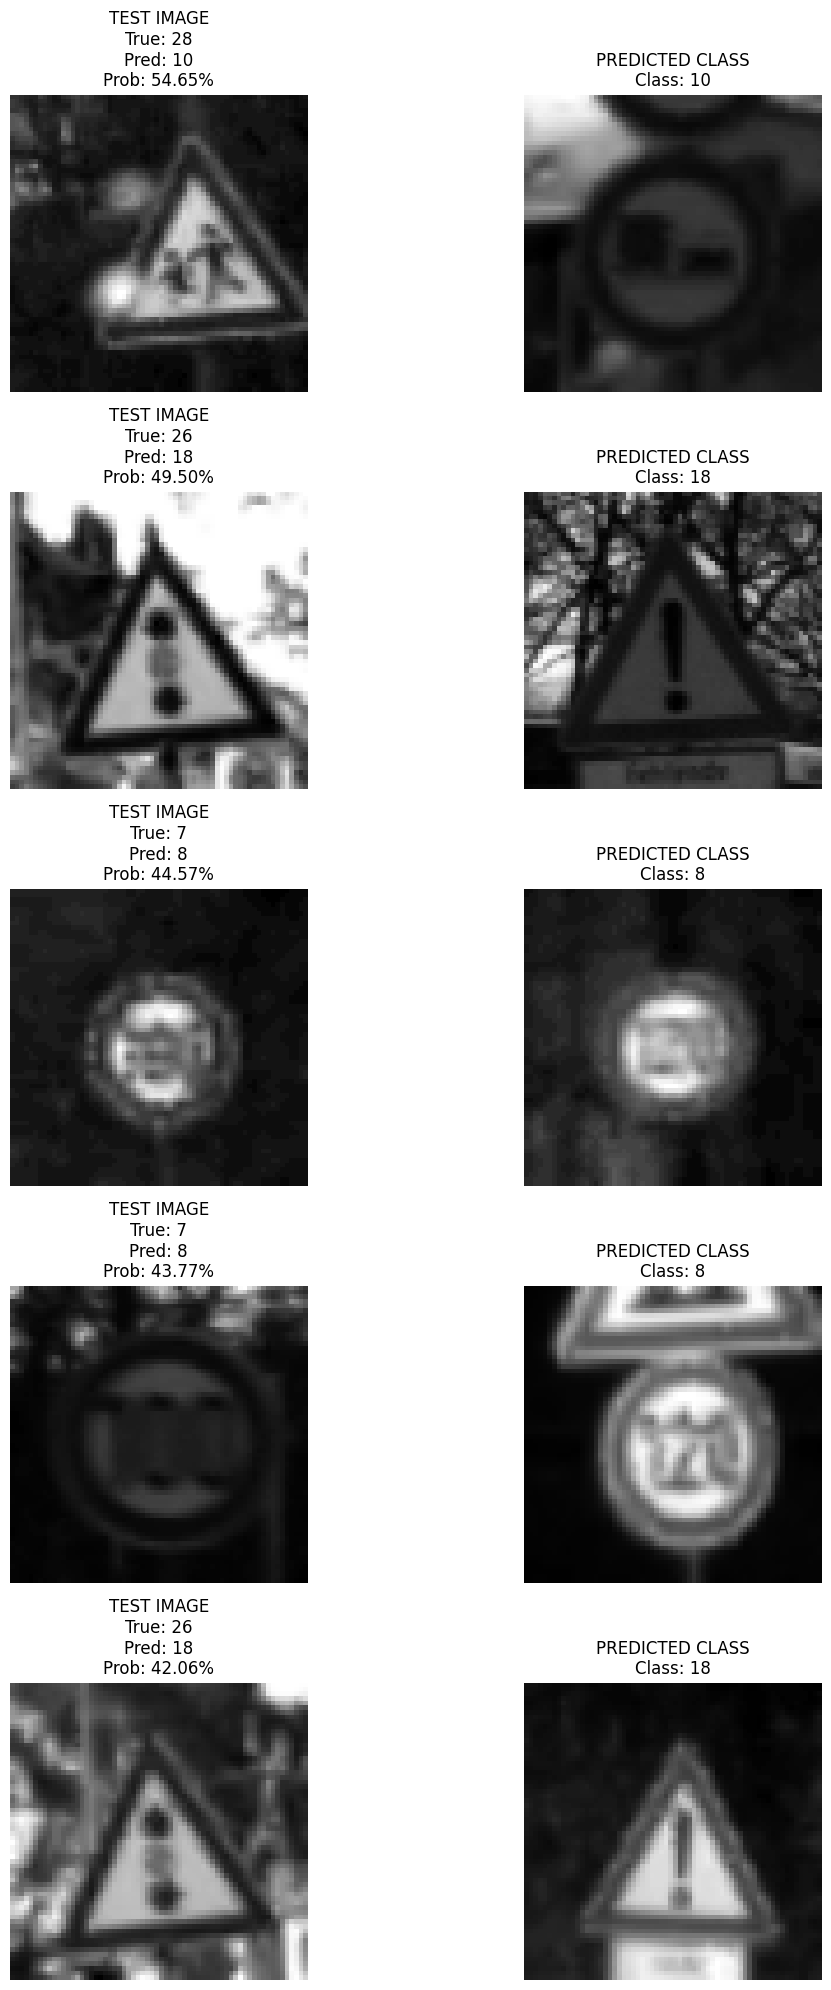

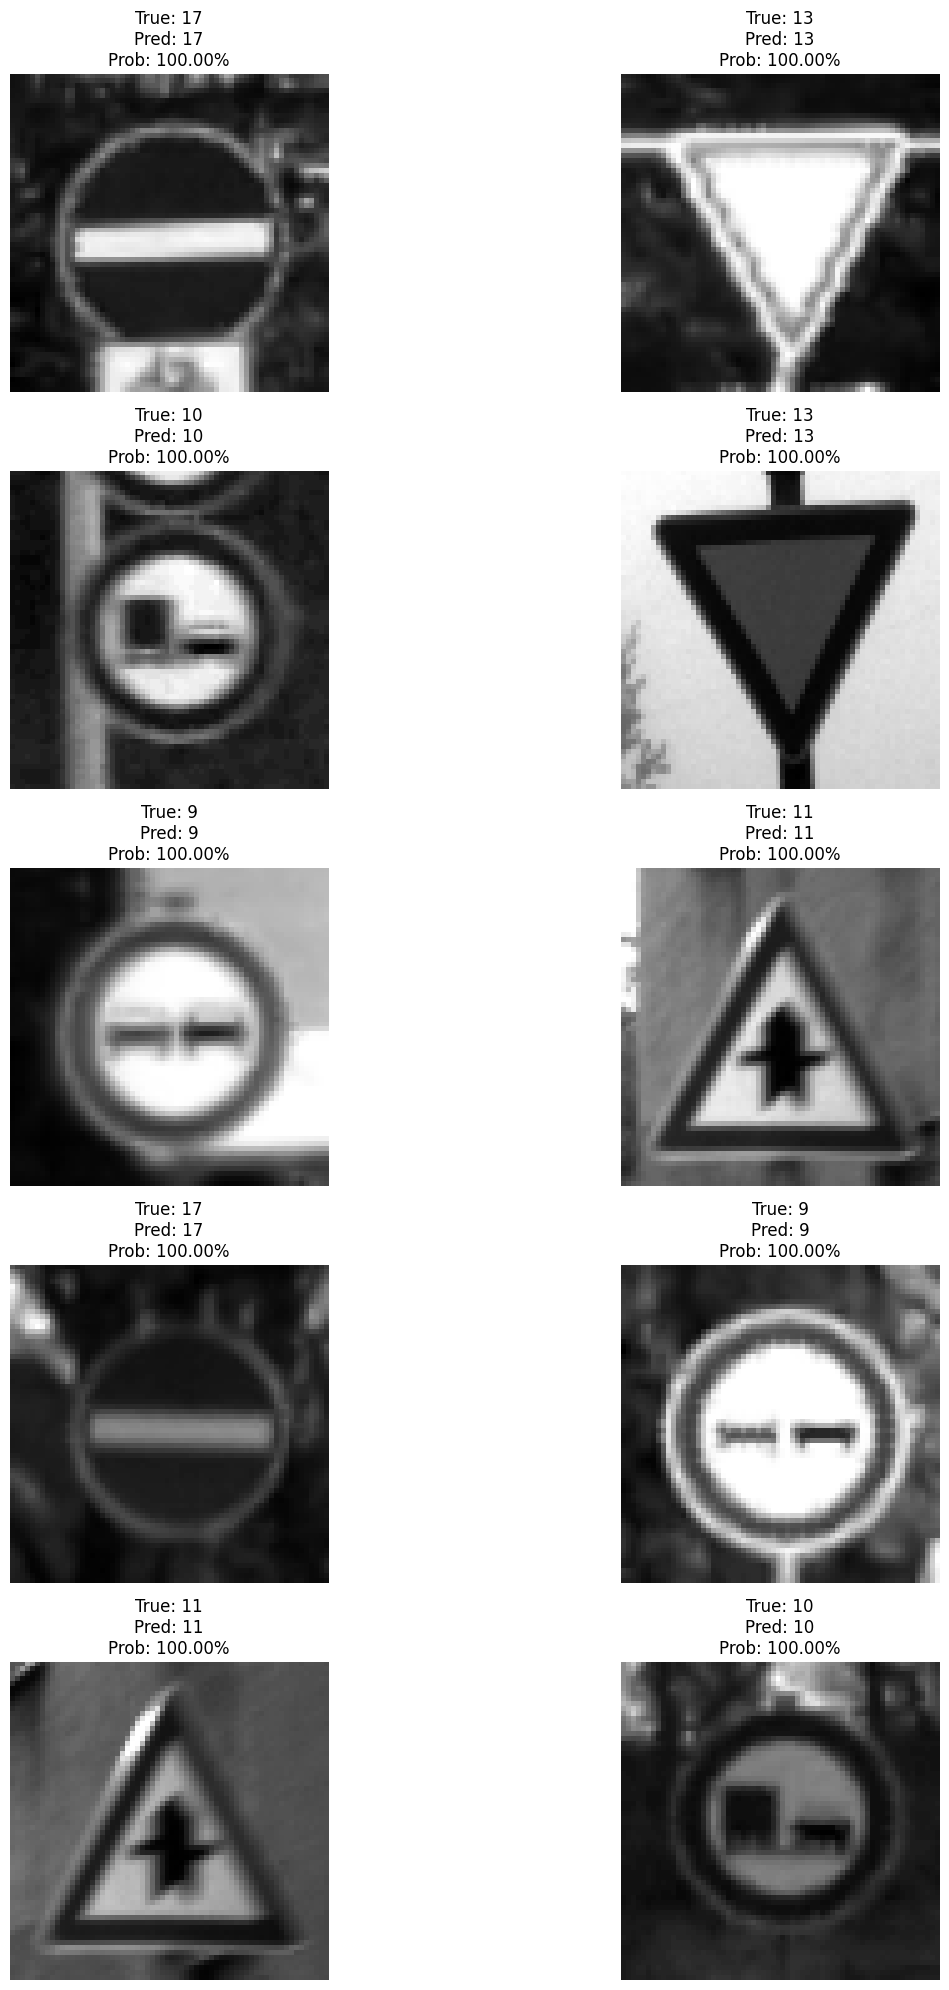

In [31]:
y_pred = model.predict(X_test_gray)
y_prob = model.predict_proba(X_test_gray)
show_top_wrong_predictions(
    X_test_gray,
    y_test_gray,
    y_pred,
    y_prob,
    X_train_gray,
    y_train_gray,
    grayscale=True
)
show_top_correct_predictions(
    X_test_gray,
    y_test_gray,
    y_pred,
    y_prob,
    grayscale=True
)

## Zobrazení pomocí Confusion Matrix

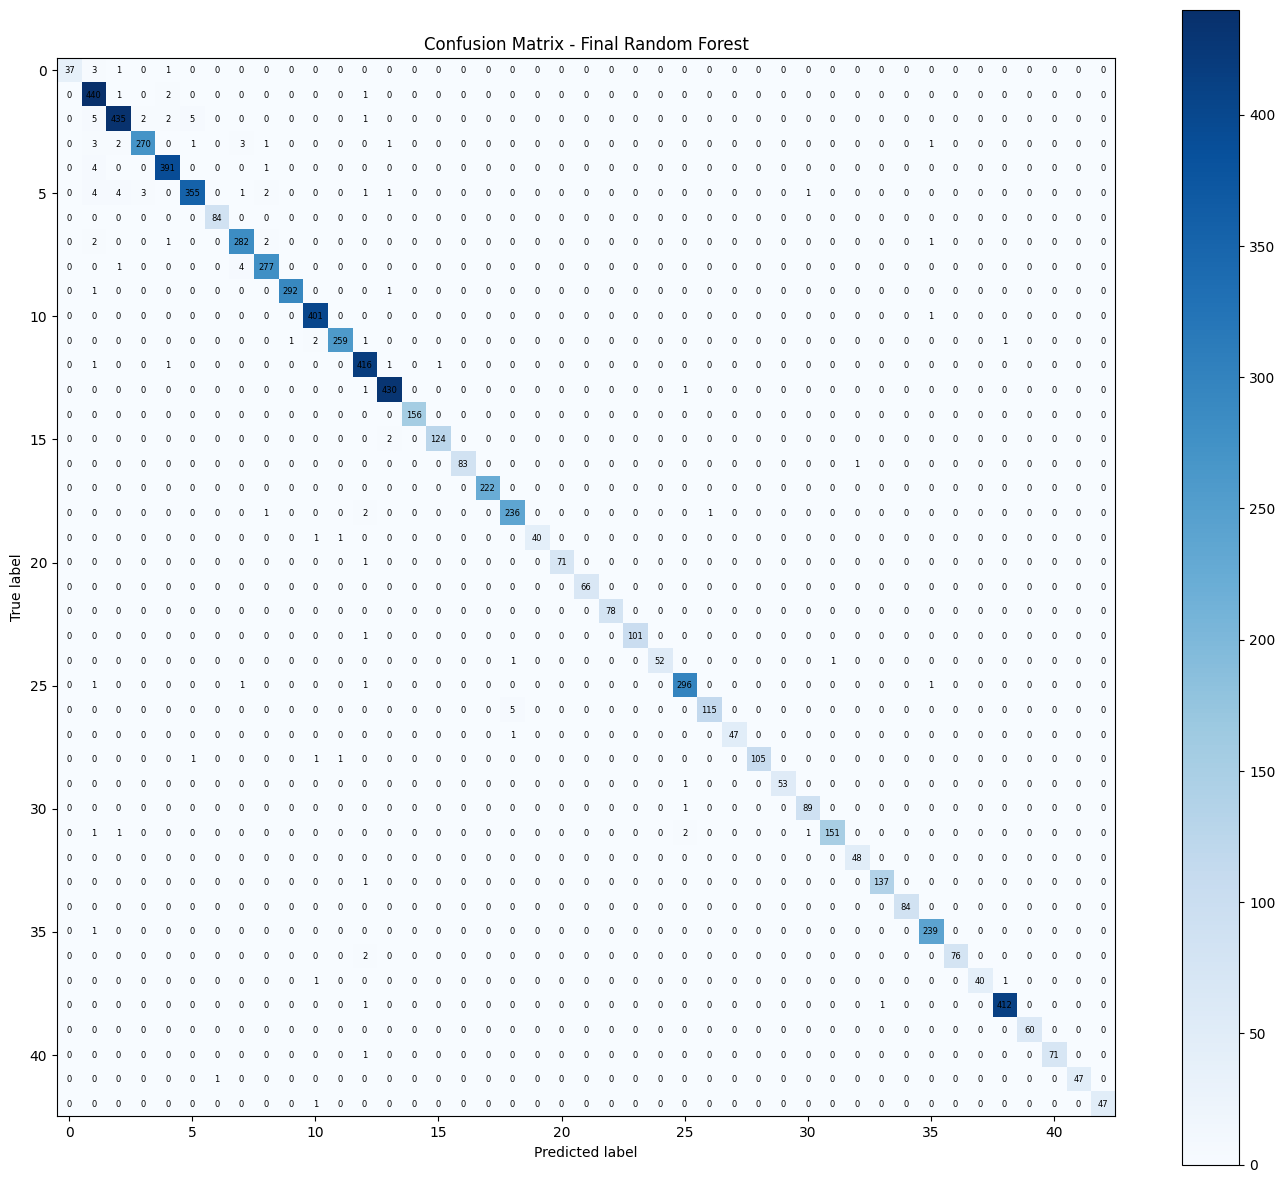

In [32]:
cm = confusion_matrix(y_test_gray, y_pred)

plt.figure(figsize=(14,12))

plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix - Final Random Forest")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.colorbar()

# čísla do buněk
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=6)

plt.tight_layout()
plt.show()

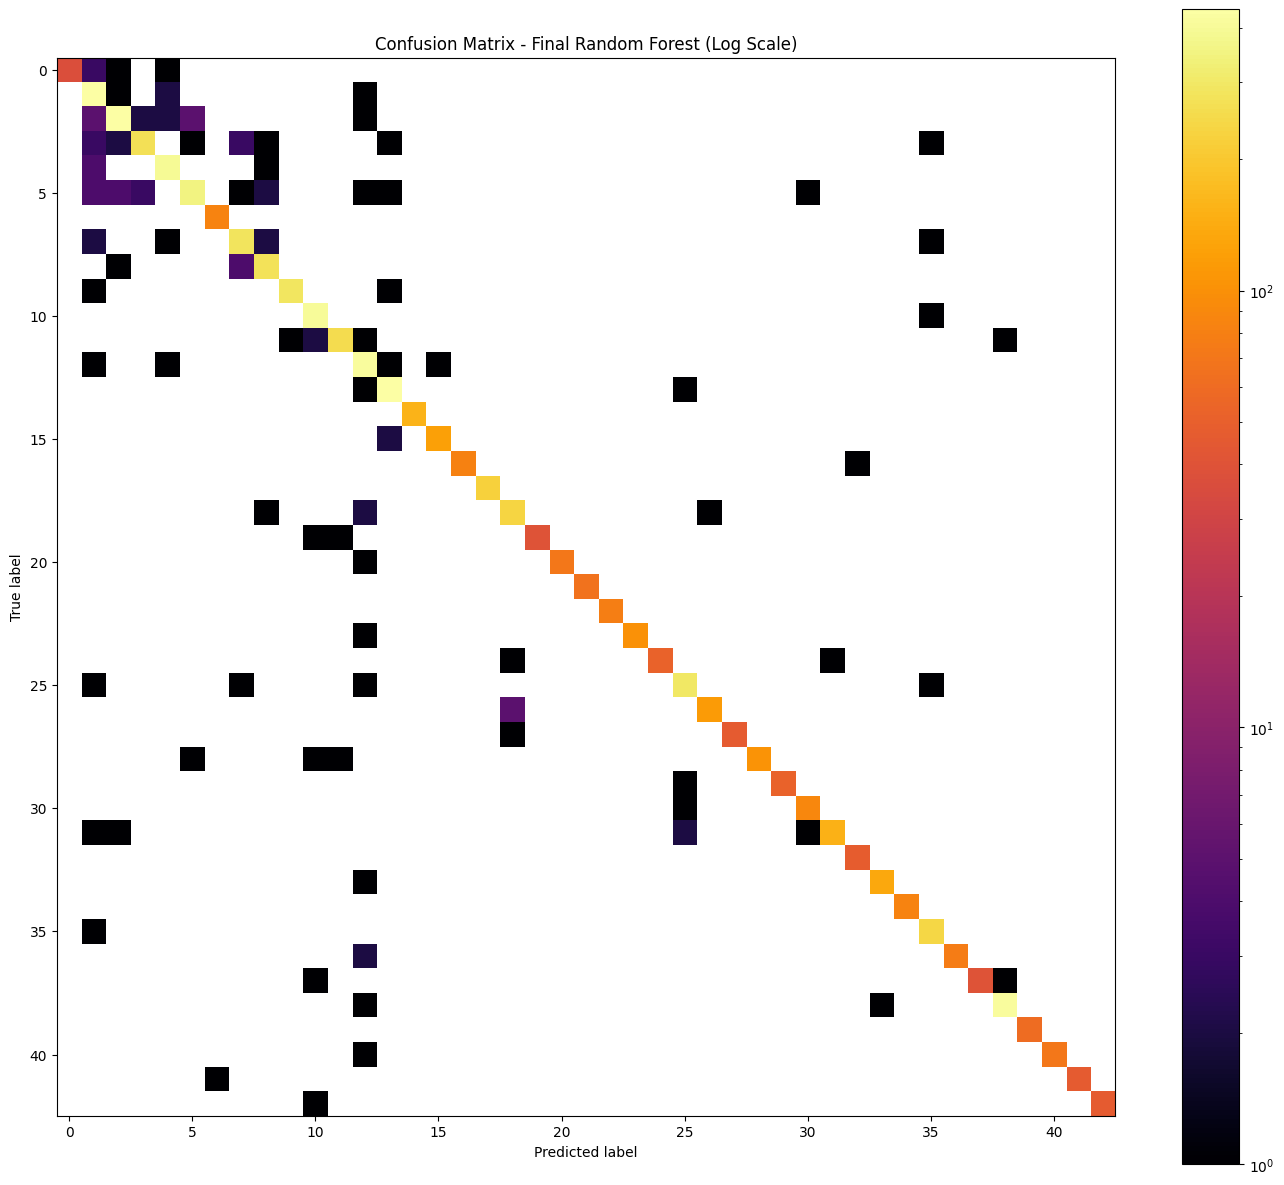

In [33]:
cm = confusion_matrix(y_test_gray, y_pred)

plt.figure(figsize=(14,12))

plt.imshow(
    cm,
    cmap="inferno",
    norm=LogNorm(vmin=1, vmax=cm.max())
)

plt.title("Confusion Matrix - Final Random Forest (Log Scale)")
plt.xlabel("Predicted label")
plt.ylabel("True label")

plt.colorbar()

plt.tight_layout()
plt.show()

## Feature Importance Heatmap

Počet features: 4096


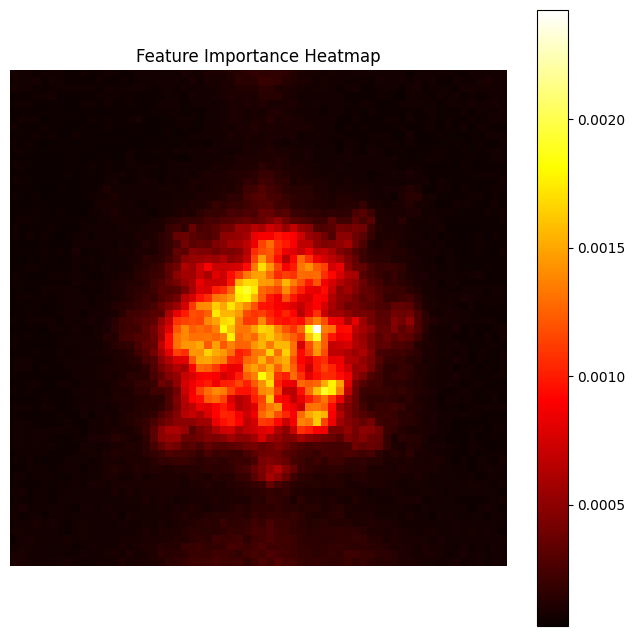

In [34]:
# důležitosti pixelů
importances = model.feature_importances_

print("Počet features:", len(importances))

# zpět do 64x64
importance_map = importances.reshape(IMG_SIZE, IMG_SIZE)

# heatmap
plt.figure(figsize=(8,8))

plt.imshow(importance_map, cmap="hot")
plt.title("Feature Importance Heatmap")
plt.colorbar()

plt.axis("off")
plt.show()

## Výběr Top pixelů

In [35]:
# vyber top N pixelů
TOP_N = 2000

important_indices = np.argsort(importances)[-TOP_N:]

print("Vybráno pixelů:", len(important_indices))

# zmenšená data
X_train_selected = X_train_gray[:, important_indices]
X_test_selected = X_test_gray[:, important_indices]

print("Nový shape X_train:", X_train_selected.shape)
print("Nový shape X_test:", X_test_selected.shape)

Vybráno pixelů: 2000
Nový shape X_train: (31367, 2000)
Nový shape X_test: (7842, 2000)


## Random Forest s omezenými features

In [36]:
model_selected = RandomForestClassifier(
    n_estimators=300,
    max_depth=42,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)

print("Trénování modelu jen na důležitých pixelech...")

start_train = time.time()

model_selected.fit(X_train_selected, y_train_gray)

end_train = time.time()

train_time = end_train - start_train

print(f"Training time: {train_time:.2f} s")

# inference
start_inference = time.time()

y_pred_selected = model_selected.predict(X_test_selected)

end_inference = time.time()

inference_time = end_inference - start_inference
avg_inference = inference_time / len(X_test_selected)

# metriky
accuracy = accuracy_score(y_test_gray, y_pred_selected)
f1 = f1_score(y_test_gray, y_pred_selected, average="weighted")

print("\n===== VÝSLEDKY =====")
print(f"Počet pixelů: {TOP_N}")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Training time: {train_time:.2f} s")
print(f"Inference time: {inference_time:.4f} s")
print(f"Průměrná inference na obrázek: {avg_inference*1000:.4f} ms")

Trénování modelu jen na důležitých pixelech...
Training time: 16.28 s

===== VÝSLEDKY =====
Počet pixelů: 2000
Accuracy: 0.9834
F1 Score: 0.9834
Training time: 16.28 s
Inference time: 0.2549 s
Průměrná inference na obrázek: 0.0325 ms


# 5. Model, 2D CNN

In [ ]:
# ============================================
# Příprava dat
# ============================================

X_train_cnn = X_train_rgb.reshape(-1, 64, 64, 3)
X_test_cnn = X_test_rgb.reshape(-1, 64, 64, 3)

print("CNN train shape:", X_train_cnn.shape)
print("CNN test shape:", X_test_cnn.shape)

# ============================================
# Model
# ============================================

model = Sequential([

    Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation="relu",
        input_shape=(64,64,3)
    ),

    MaxPooling2D(pool_size=(2,2)),

    Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation="relu"
    ),

    MaxPooling2D(pool_size=(2,2)),

    Conv2D(
    filters=128,
    kernel_size=(3,3),
    activation="relu"
    ),

    MaxPooling2D(pool_size=(2,2)),

    Flatten(),

    Dense(
        128,
        activation="relu"
    ),

    Dropout(0.3),

    Dense(
        43,
        activation="softmax"
    )
])

# ============================================
# Kompilace
# ============================================

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# ============================================
# Trénink
# ============================================
checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)
print("Trénování CNN modelu...")

start_train = time.time()

history = model.fit(
    X_train_cnn,
    y_train_rgb,
    epochs=100,
    batch_size=64,
    validation_split=0.1,
    callbacks=[checkpoint],
    verbose=1
)

end_train = time.time()

train_time = end_train - start_train
best_model = load_model(
    "best_model.keras"
)
print(f"Training time: {train_time:.2f} s")
# ============================================
# Inference
# ============================================

print("Probíhá inference...")

start_inference = time.time()

y_prob = best_model.predict(
    X_test_cnn
)

y_pred = np.argmax(y_prob, axis=1)

end_inference = time.time()

inference_time = end_inference - start_inference

avg_inference = inference_time / len(X_test_cnn)

# ============================================
# Výsledek
# ============================================

accuracy = accuracy_score(y_test_rgb, y_pred)

f1 = f1_score(
    y_test_rgb,
    y_pred,
    average="weighted"
)

print("\n===== VÝSLEDKY =====")
best_epoch = np.argmax(
    history.history["val_accuracy"]
) + 1

print(
    "Nejlepší epocha:",
    best_epoch
)

print(
    "Nejlepší val_accuracy:",
    max(history.history["val_accuracy"])
)
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Training time: {train_time:.2f} s")

print(f"Inference time celkem: {inference_time:.4f} s")

print(f"Průměrná inference na obrázek: {avg_inference*1000:.4f} ms")

CNN train shape: (31367, 64, 64, 3)
CNN test shape: (7842, 64, 64, 3)


d:\Data\Škola\Usu_2\projekt\venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 688,747 (2.63 MB)

 Trainable params: 688,747 (2.63 MB)

 Non-trainable params: 0 (0.00 B)

Trénování CNN modelu...
Epoch 1/100
442/442 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.2931 - loss: 2.5984
Epoch 1: val_accuracy improved from None to 0.86675, saving model to best_model.keras
442/442 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.4961 - loss: 1.7673 - val_accuracy: 0.8668 - val_loss: 0.4820
Epoch 2/100
439/442 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8344 - loss: 0.5335
Epoch 2: val_accuracy improved from 0.86675 to 0.97800, saving model to best_model.keras
442/442 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.8693 - loss: 0.4202 - val_accuracy: 0.9780 - val_loss: 0.1019
Epoch 3/100
440/442 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9267 - loss: 0.2359
Epoch 3: val_accuracy improved from 0.97800 to 0.98502, saving model to best_model.keras
442/442 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.9346 - loss: 0.2118 - val_accuracy: 0.9850 - val_loss: 0.0695
Epoch 4/100
440/442 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9537 - loss: 0.1475
Epo

Udělal jsem test se 100 epochami a nechal si vypsat v jaké bylo dosaženo nevějších procest accuracy. Nejvyšší validační přesnosti bylo dosaženo v 79. epoše a to 99.904 %. Avšak výsledná přesnost na testovací množině nedosáhla lepší hodnoty než model trénovaný pomocí 50 epoch. <br>
Z důvodu rychlosti, celý tento poces trval 20 minut a řekl bych, že není potřeba kód spouštět znovu. <br>
Zvolil jsem variantu 50 epoch, která je ukázana níže.

In [15]:

# ============================================
# Příprava dat
# ============================================

X_train_cnn = X_train_rgb.reshape(-1, 64, 64, 3)
X_test_cnn = X_test_rgb.reshape(-1, 64, 64, 3)

print("CNN train shape:", X_train_cnn.shape)
print("CNN test shape:", X_test_cnn.shape)

# ============================================
# Model
# ============================================

model = Sequential([

    Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation="relu",
        input_shape=(64,64,3)
    ),

    MaxPooling2D(pool_size=(2,2)),

    Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation="relu"
    ),

    MaxPooling2D(pool_size=(2,2)),

    Conv2D(
    filters=128,
    kernel_size=(3,3),
    activation="relu"
    ),

    MaxPooling2D(pool_size=(2,2)),

    Flatten(),

    Dense(
        128,
        activation="relu"
    ),

    Dropout(0.3),

    Dense(
        43,
        activation="softmax"
    )
])

# ============================================
# Kompilace
# ============================================

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# ============================================
# Trénink
# ============================================
print("Trénování CNN modelu...")

start_train = time.time()

history = model.fit(
    X_train_cnn,
    y_train_rgb,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

end_train = time.time()

train_time = end_train - start_train

print(f"Training time: {train_time:.2f} s")
# ============================================
# Inference
# ============================================

print("Probíhá inference...")

start_inference = time.time()

y_prob = model.predict(X_test_cnn)

y_pred = np.argmax(y_prob, axis=1)

end_inference = time.time()

inference_time = end_inference - start_inference

avg_inference = inference_time / len(X_test_cnn)

# ============================================
# Výsledky
# ============================================

accuracy = accuracy_score(y_test_rgb, y_pred)

f1 = f1_score(
    y_test_rgb,
    y_pred,
    average="weighted"
)

print("\n===== VÝSLEDKY =====")

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Training time: {train_time:.2f} s")

print(f"Inference time celkem: {inference_time:.4f} s")

print(f"Průměrná inference na obrázek: {avg_inference*1000:.4f} ms")

CNN train shape: (31367, 64, 64, 3)
CNN test shape: (7842, 64, 64, 3)


d:\Data\Škola\Usu_2\projekt\venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 688,747 (2.63 MB)

 Trainable params: 688,747 (2.63 MB)

 Non-trainable params: 0 (0.00 B)

Trénování CNN modelu...
Epoch 1/50
442/442 ━━━━━━━━━━━━━━━━━━━━ 16s 34ms/step - accuracy: 0.5637 - loss: 1.5466 - val_accuracy: 0.9401 - val_loss: 0.2622
Epoch 2/50
442/442 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.9079 - loss: 0.2993 - val_accuracy: 0.9790 - val_loss: 0.0954
Epoch 3/50
442/442 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.9549 - loss: 0.1534 - val_accuracy: 0.9885 - val_loss: 0.0439
Epoch 4/50
442/442 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - accuracy: 0.9700 - loss: 0.0997 - val_accuracy: 0.9917 - val_loss: 0.0338
Epoch 5/50
442/442 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - accuracy: 0.9769 - loss: 0.0771 - val_accuracy: 0.9930 - val_loss: 0.0267
Epoch 6/50
442/442 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.9825 - loss: 0.0550 - val_accuracy: 0.9920 - val_loss: 0.0368
Epoch 7/50
442/442 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - accuracy: 0.9840 - loss: 0.0507 - val_accuracy: 0.9968 - val_loss: 0.0178
Epoch 8/50
442/442 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 

Výpis špatně zařazených obrázků, všechny jelikož je jich málo

Počet chyb: 18


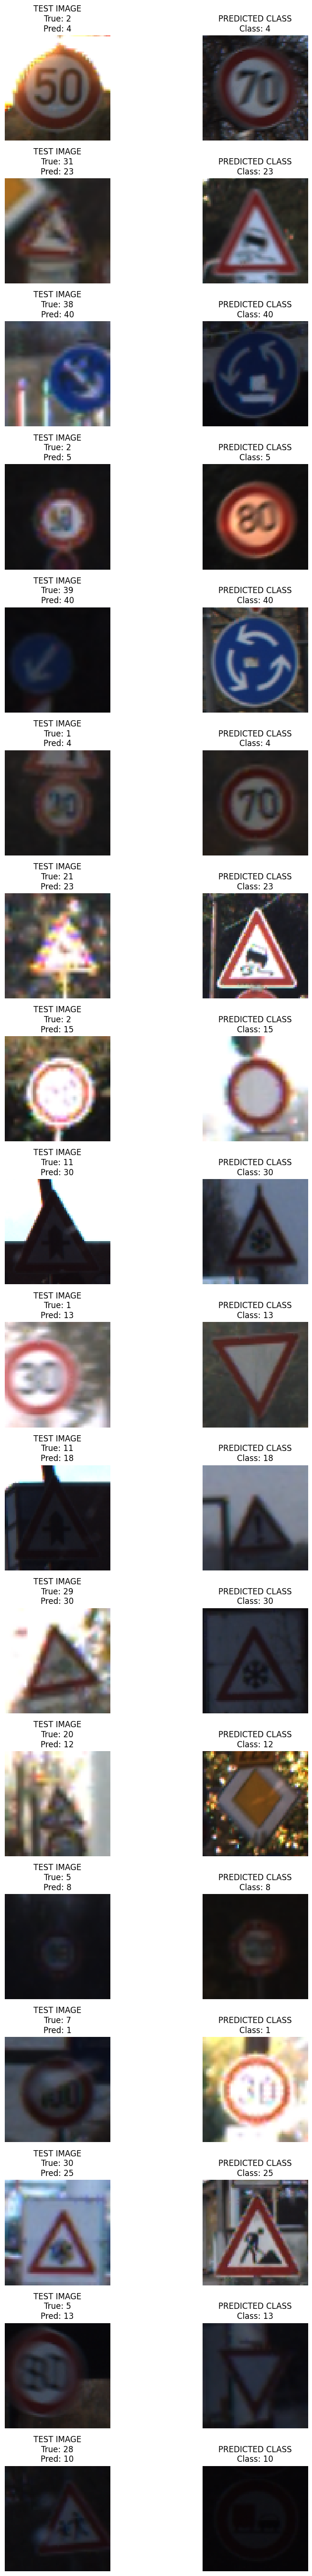

In [16]:
wrong_indices = np.where(y_test_rgb != y_pred)[0]

print(f"Počet chyb: {len(wrong_indices)}")

plt.figure(figsize=(10, len(wrong_indices) * 3))

for i, idx in enumerate(wrong_indices):

    true_class = y_test_rgb[idx]
    pred_class = y_pred[idx]

    # ============================================
    # Chybně klasifikovaný obrázek
    # ============================================

    plt.subplot(len(wrong_indices), 2, i*2 + 1)

    img = X_test_rgb[idx].reshape(64, 64, 3)

    plt.imshow(img)

    plt.title(
        f"TEST IMAGE\n"
        f"True: {true_class}\n"
        f"Pred: {pred_class}"
    )

    plt.axis("off")

    # ============================================
    # Obrázek predikované třídy
    # ============================================

    pred_indices = np.where(
        y_train_rgb == pred_class
    )[0]

    random_idx = np.random.choice(
        pred_indices
    )

    pred_img = X_train_rgb[random_idx].reshape(
        64,
        64,
        3
    )

    plt.subplot(len(wrong_indices), 2, i*2 + 2)

    plt.imshow(pred_img)

    plt.title(
        f"PREDICTED CLASS\n"
        f"Class: {pred_class}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [17]:
wrong_indices = np.where(y_test_rgb != y_pred)[0]

print(f"Počet chyb: {len(wrong_indices)}\n")

for idx in wrong_indices:
    print(
        f"Index: {idx:4d} | "
        f"True: {y_test_rgb[idx]:2d} | "
        f"Pred: {y_pred[idx]:2d} | "
        f"Confidence: {np.max(y_prob[idx])*100:.2f}%"
    )

Počet chyb: 18

Index:  112 | True:  2 | Pred:  4 | Confidence: 61.51%
Index:  307 | True: 31 | Pred: 23 | Confidence: 66.69%
Index:  788 | True: 38 | Pred: 40 | Confidence: 61.84%
Index: 2348 | True:  2 | Pred:  5 | Confidence: 60.23%
Index: 3584 | True: 39 | Pred: 40 | Confidence: 87.10%
Index: 4600 | True:  1 | Pred:  4 | Confidence: 99.96%
Index: 4603 | True: 21 | Pred: 23 | Confidence: 99.31%
Index: 4660 | True:  2 | Pred: 15 | Confidence: 93.07%
Index: 4783 | True: 11 | Pred: 30 | Confidence: 76.03%
Index: 5092 | True:  1 | Pred: 13 | Confidence: 100.00%
Index: 5122 | True: 11 | Pred: 18 | Confidence: 99.95%
Index: 5623 | True: 29 | Pred: 30 | Confidence: 75.39%
Index: 5669 | True: 20 | Pred: 12 | Confidence: 75.93%
Index: 5974 | True:  5 | Pred:  8 | Confidence: 95.84%
Index: 6576 | True:  7 | Pred:  1 | Confidence: 54.51%
Index: 6648 | True: 30 | Pred: 25 | Confidence: 99.74%
Index: 6844 | True:  5 | Pred: 13 | Confidence: 99.85%
Index: 7651 | True: 28 | Pred: 10 | Confidence: 

### Zde jsou výsledky a kombinace, které jsem zkoušel

input_shape=(64,64,1) - grayscale - 10 Epoch <br>
===== VÝSLEDKY ===== <br>
Accuracy: 0.9878<br>
F1 Score: 0.9878<br>
Training time: 99.05 s<br>
Inference time celkem: 1.6444 s<br>
Průměrná inference na obrázek: 0.2097 ms<br>


input_shape=(64,64,3) - RGB - 10 Epoch <br>
===== VÝSLEDKY =====<br>
Accuracy: 0.9902<br>
F1 Score: 0.9902<br>
Training time: 185.55 s<br>
Inference time celkem: 2.5885 s<br>
Průměrná inference na obrázek: 0.3301 ms<br>

input_shape=(64,64,3) - RGB - 10 Epoch - Conv2D(128)<br>
===== VÝSLEDKY =====<br>
Accuracy: 0.9927<br>
F1 Score: 0.9927<br>
Training time: 113.45 s<br>
Inference time celkem: 1.7212 s<br>
Průměrná inference na obrázek: 0.2195 ms<br>

input_shape=(64,64,3) - RGB - 50 Epoch - Conv2D(128)<br>
===== VÝSLEDKY =====<br>
Accuracy: 0.9977<br>
F1 Score: 0.9977<br>
Training time: 608.87 s<br>
Inference time celkem: 2.0105 s<br>
Průměrná inference na obrázek: 0.2564 ms<br>

# Celý postup

Začal jsem výběrem dat. Hledal jsem na stránce Kaggle a zalíbil se mi dataset GTSRB - German Traffic Sign Recognition Benchmark, převážně jelikož měl hodně dat.

Vybral jsem si jaké modely budu používat, jako baseline jsem zvolil lineární regresi, když jsem o tom mluvil na přednášce.

Zvolil jsem si další modely, které bych chtěl použít a porovnat.

Vzal jsem data, vypsal si kolik má tříd, zda jsou třídy vyrovnané a také jsem si nechal zobrazit náhodné značky, abych měl představu jak to vypadá.

Jelikož obrázky mají každá jinou velikost, tak jsem si kódem nechat zjistit jejich největší, nejmenší a průměrnou velikost a i medián. Pomocí toho jsem zvolil velikost a do té všechny obrázky sjednotil. Zvolil jsem 64x64 pixelů.

Poté jsem začal s modely. Můj baseline model, měl docela velká procesta accuracy a to 95.7 %, tak jsem si nebyl jistý, zda to nějaký jiné model překoná.

- U každého modelu jsem si nechal vypsat:
    - celkový počet vstupních dat a počet features
    - počet labels, neboli správných odpovědí
    - počet trénovacích dat
    - počet testovacích dat
    - čas tréninku ve vteřinách
- A také výsledky:
    - accuracy 
    - F1 score
    - čas inference ve vteřinách
    - průměrná doba inference na obrázek v mili-vteřinách
    - Classification Report
- K tomu Top 5 nejproblematičtějích výsledků s predicí a správnou odpovědí




### První model, který jsem si zvolil byl Support Vector Machine - SVM

Originální SVM model se neupraveným vstupem ani netuším jak dopadl, jelikož jsem ho po asi 94 minutách průběhu vypl a právě začal řešit jak udělat, aby to netrvalo tak dlouho a rozhodl jsem se použít Grayscale. Po upravení dat pomocí grayscale, jsem nechal model běžet asi 28 minut a následně běh přerušil, jelikož by to stejně nemělo smysl nechávat dojet do konce. Samozřejmě by mne zajímal výsledek u obou případů, ale na to nebyla síla ani čas. <br>
Abych měl alespoň nějaký vysledek, rozhodl jsem se použít LinearSVC. Má sice menší přesnost než SVM, ale je mnohem rychlejší.  <br>
Ani to ve výsledku nepomohlo a asi po 35 minutách, jsem model zastavil a přidal ještě Principal Component Analysis (PCA) pro redukci komponentů, abych ten model dokázal spustit. <br>
Původní počet komponentů s RGB 12288, po aplikaci grayscale byl počet 4096. Použil jsem PCA redukci, abych zjistil s jakým počtem se mi model vlastně spustí a doběhne v přijatelném čase. <br>
Jako prvotní počet jsem si zvolil 500 komponentů, načež proces proběhl docela rychle a tak jsem zkoušel jiné počty komponent. Zkusil jsem hodnoty 100, 500, 1000. <br>
Nejlépe vycházelo 500 komponentů s accuracy 88.42 % a časem tréninku 151.95 s. S časem celkové inference 0.0044 s, což je extrémně rychlé. <br>
Ostatní varianty, například 1000 komponentů, mělo menší accuracy a ještě k tomu 4x větší training time.




### Druhý model, který jsem si zvolil byl Random Forest

U tohoto modelu jsem rovnou začal s variantou grayscale a 500 komponent pomocí PCA, jelikož po předchozích zkušenostech jsem tomu moc nevěřil, tím myslím časově. <br>
K mému velkému překvapení, celý proces spuštění kódu trval jen několiv vteřin a training time byl jen 7.98 s a to s accuracy 80 %. <br>
Odebral jsem PCA a nechal jen grayscale data. Training time byl 8.52 s a accuracy byla 97.65 %, což byl dost slušný výsledek a poprvné lepší než baseline model. <br>
Rozhodl jsem tedy dát jako vstupní data RGB obrázky. Tentokrát trval proces déle a to 16.50 s, ale s tím se muselo počítat, když se načítá 3x větší objem informací. Výsledná accuracy byla 97.68 %, což bylo lepší, ale problém nastal v času celkové inference a to rozdíl 0.2818 s, přičemž grayscale vstup měl výsledný čas inference 0.1508 s. <br>
To mě vedlo k preferenci grayscale verze a to z důvodu rychlosti, proti tomu rozdíl 0.03 % byl zanedbatelný.

### Třeří model, který jsem si zvolil byl k-nearest neighbors (KNN)

Jako vstup modelu jsem použil grayscale data. <br>
Rychlost byla v pořádku s porovnáním ostatních modelů a to training time 0.12 s, ale to není nic co by hrálo roli, kvůli funkčnosti KNN. Naopak celkový čas inference 7.2844 s je opravdu hodně. <br>
Accuracy 86.85 % byla nic moc. <br>
Zkusil jsem si pohrát s počtem sousedů, defaultně jsem měl nastaveno 5, takže jsem zkusil dát 15 s výslednou accuracy 78.14 %, dále 10 nebo 8 sousedy. Zkusil jsem i 4 sousedy s 88 % a 2 sousedy s 91 %. <br>
Bylo hezké vidět 91 % s 2 sousedy, ale to by dělalo model hrozně nestabilní a tak jsem se bez dalších úprav rovnou posunul k dalšímu modelu.

### Čtvrtý model, který jsem si zvolil byl Decision Tree

Opakovaně jsem zvolil pro vstup již upravená grayscale data.
Model měl training time 117.45 s, s ne úplně ideální accuracy a to 72.97 % ba naopak s rychlou celkovou dobou inference 0.0844 s. <br> 
To mne ale nepřesvědčilo, abych na modelu dále pracoval a tímto jsem zakončil zkoušení modelů.

### Finální model

Jako finální model a pro následný "tuning" jsem si zvolil model Random Forest s grayscale vstupem, jelikož byl znatelně rychlý oproti ostatním, celková doba inference byla také lepší než ostatní. Lepší byly jen Logistická regrese a Decision Tree. Ale hlavní co rozhodlo, byla výsledná accuracy a F1 score oboje s 97.65 %. <br>

### Tuning Random Forest

Pro dosažení nejlepšího výsledku jsem se rozhodl si pohrát s hodnotami:
 - n_estimators             (počet stromů)
 - max_depth                (jak hluboký strom může být)
 - min_samples_split        (kolik vrozků musí být, aby se strom ještě dělil)

Abych dosáhl tohoto výsledku, rozhodl jsem se udělat search loop, do kterého jsem vložil různé kombinace hodnot těchto proměnných a model mi sám řekl, co je nejlepší. <br>
 - n_estimators_list = [100, 200, 300]
 - max_depth_list = [20, 30, None]
 - min_samples_split_list = [2, 5, 10]

Výsledek jsem dostal jednoznačný a to:
 - n_estimators: 300
 - max_depth: None
 - min_samples_split: 2

K tomu byla accuracy 98.52 % a to samé i F1 Score. <br>
Čas tréninku byl 34.69 vteřin a celková doba inference 0.3663 s. <br>
Doba inference byla o dost větší, ale s tím že se použilo 300 stromů namísto 100, bylo logické, že se tento čas zvedne. Tedy čas na jeden obrázek je cca 0.046 ms. <br>

Moc se mi nelíbylo, že hodnota max_depth byla None a tak jsem se rozhodl zjistit maximální, minimální a průměrnou hloubku. <br>
Největší hloubka mi vyšla 42 a průměrná 30,59. <br>
Zkusil jsem další search loop, ale tentokrát jsem nechal hodnotu n_estimators na 300 a hledal jen zbylé dvě:
 - max_depth_list = [35, 40, 42]
 - min_samples_split_list = [2, 3, 4, 5]

Vyšlo mi:
 - accuracy: 0.9853
 - F1 Score: 0.9853
 - n_estimators: 300
 - max_depth: 42
 - min_samples_split: 2
 - Training time: 30.76 s
 - Inference time: 0.3356 s

A tento výsledek jsem se rozhodl akceptovat a zvolit jako můj skoro finální výstup.

### Zhodnocení modelu a Confusion matrix

Abych zjistil kde model dělá chyby a naopak kde se mu daří nejvíc, jsem zvolil výpis Top 10 nejlepších a Top 10 nejhorších výsledků a k tomu confusion matrix. <br>
Výsledky mne moc nepřekvapily a ve finále mi i docela dávají smysl. <br>
Model má největší přesnost ve značkách jako je "Dej přednost v jízdě", což je převrácený trojúhelník, u kterého si je model 100 % jistý a zadruhé u značek "Zákaz předjíždění" a to jak osobním či nákladním vozům, si je model jistý také 100 %. <br>
Confusion matrix jsem se rozhodl nechat si vypsat 2 různé. A to jeden s bílým až modrým rozmezím s číslamy a druhý s logaritmovanými hodnotami v rozmení od černé barvy po žlutou. Kde jsou krásně vidět právě až černé kostičky, kde se modelu nedařilo. <br>


### Úprava features

Koncem mé práce jsem si ještě chtěl pohrát s počtem features a zkusit, zda tento počet nemohu nějak zredukovat. <br>
Udělal jsem Feature Importance Heatmap, tak nějak jsem vytušil z výsledku, že všechen počet vstupních pixelů nebude třeba, jelikož na co se model hlavně soustředí, je logicky samotná dopravní značka.  <br>
Vybral jsem tedy počty 500, 1000 a 2000 vstupních features. <br>
Varianta s 2000 features měla výslednou accuracy nejblíže předešlému výsledku modelu a to namísto 98.53 %, vyšlo 98.34 %. <br>
Hlavní rozdíl ale nastal v čase tréninku a celkové inference, jejichž hodnoty byly znatelně menší:
 - Training time: 28.55 s    ->  14.83 s
 - Inference time: 0.3477 s  ->  0.2400 s

Což vycházelo na průměrnou dobu na obrázek 0.0287 ms

### Závěr

Na závěr jsem ještě chtěl vědět, zda hodnoty zvolené pro Random Forest s grayscale úpravou, bude stejný pro vstup RGB obrázků a měl jsem pravdu. Pro hodnoty n_estimators, max_depth, min_samples_split jsem dostal identický výsledek s o 0.17% lepší accuracy, ale až skoro dvojnásobným trénovacím časem a také skoro dvojnásobnou celkovou dobou inference. <br>

Proto jsem se rozhodl jako můj finální výsledný nejlepší model zvolit: <br>
 - **Random Forest** s:
    - grayscale
    - features selection TOP 2000
    - n_estimators = 300
    - max_depth = 42
    - min_samples_split = 2

 - **Výsledné hodnoty**:
    - Accuracy: 98.34 %
    - F1 Score: 98.34 %
    - Training time: 14.83 s
    - Inference time: 0.2248 s

### Přidání modelu 2D CNN

Na doporučení jsem přidal ještě model 2D CNN

Jeho výsledky jsou mnohem lepší a úplně nejlepší, oproti všech ostatním modelům.

Finální výsledek, který jsem rozhodl vybrat jako optimální a stabilní je:
input_shape=(64,64,3) = RGB <br>
50 Epoch - Conv2D(128)<br>
S výsledky: <br>
Accuracy: 0.9977<br>
F1 Score: 0.9977<br>
Training time: 608.87 s<br>
Inference time celkem: 2.0105 s<br>
Průměrná inference na obrázek: 0.2564 ms<br>

Docela důležitá věc co bych chtěl zmínit na závěr, že když se podívám na obrázky, které model určil špatně, tak u většiny z nich si byl model jistý na 90+ %, což není moc pozitivní. <br>
Ale když se podíváme na srovnání predikce oproti reálné třídě, tak jsou obrázky dost podobné, některé dost rozmazané a zašumělé a to platilo i u ostaních modelů.